<div style="display: flex; background-color: RGB(51, 153, 51);" >
<h1 style="margin: auto; padding: 30px; color:#fff;">ETUDE DE MARCHE - ANALYSE DES GROUPEMENTS DE PAYS</h1>
</div>

<h1 style="color:RGB(51,153,51)">
LA POULE QUI CHANTE
</h1>

<p>
<span style="color:RGB(51,153,51)">La poule qui chante </span>, une entreprise française d’agroalimentaire. Son activité principale est l’élevage et la vente de poulets sous le label <span style="color:RGB(51,153,51)">“Poulet Agriculture Biologique”</span>
</p>
<p>
Le PDG de l’entreprise souhaite évaluer la possibilité de se développer à l'international
</p>

<div style="background-color: RGB(102, 204, 102);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(102, 204, 102);" >
<h3 style="margin: auto; padding: 20px; color: RGB(102, 204, 102); ">1.1 - Importation des librairies</h3>
</div>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from matplotlib.collections import LineCollection

from sklearn import datasets
from sklearn.cluster import AgglomerativeClustering
from sklearn import preprocessing
from sklearn.metrics import confusion_matrix

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

from sklearn.cluster import KMeans

<div style="border: 1px solid RGB(102, 204, 102);" >
<h3 style="margin: auto; padding: 20px; color: RGB(102, 204, 102); ">1.2 - Chargement des fichiers</h3>
</div>

In [2]:
df_chicken_data = pd.read_csv('../datas/out/chicken_data.csv', sep=";")
df_chicken_data.head()

,Pays,Pourcentage de population urbaine,Croissance annuelle du PIB par habitant en %,PIB par habitant en US$,Stabilité politique,Émissions de CO2 par personne imputables à l'élevage,Densité des poulets dans la superficie agricole par habitant,Part des poulets dans l'élevage en %,Taux de dépendance aux importations de viande de volaille en %,Taux d'autosuffisance en viande de volaille en %
0,Afghanistan,26.409644,13.367738,396.015997,-2.484081,0.36,0.00,1.91,14.705882,85.294118
1,Afrique du Sud,65.986638,-8.012762,5976.385898,-0.665642,0.37,0.02,12.19,15.330848,86.999068
2,Albanie,67.720435,22.158933,8172.294966,0.183349,0.67,0.05,10.69,74.285714,25.714286
3,Algérie,73.661062,8.111885,5364.027937,-0.577885,0.28,0.05,27.24,0.000000,100.438596
4,Allemagne,75.933325,8.103028,53528.073268,0.586989,0.49,0.09,9.13,51.525199,101.525199


<div style="background-color: RGB(102, 204, 102);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - ACP</h2>
</div>

<div style="border: 1px solid RGB(102, 204, 102);" >
<h3 style="margin: auto; padding: 20px; color: RGB(102, 204, 102); ">2.1 - Recherche du nombre de composante</h3>
</div>

In [3]:
#La pays devient l'index du dataframe
df_chicken_data = df_chicken_data.set_index("Pays")
df_chicken_data.head()

,Pourcentage de population urbaine,Croissance annuelle du PIB par habitant en %,PIB par habitant en US$,Stabilité politique,Émissions de CO2 par personne imputables à l'élevage,Densité des poulets dans la superficie agricole par habitant,Part des poulets dans l'élevage en %,Taux de dépendance aux importations de viande de volaille en %,Taux d'autosuffisance en viande de volaille en %
Pays,,,,,,,,,
Afghanistan,26.409644,13.367738,396.015997,-2.484081,0.36,0.00,1.91,14.705882,85.294118
Afrique du Sud,65.986638,-8.012762,5976.385898,-0.665642,0.37,0.02,12.19,15.330848,86.999068
Albanie,67.720435,22.158933,8172.294966,0.183349,0.67,0.05,10.69,74.285714,25.714286
Algérie,73.661062,8.111885,5364.027937,-0.577885,0.28,0.05,27.24,0.000000,100.438596
Allemagne,75.933325,8.103028,53528.073268,0.586989,0.49,0.09,9.13,51.525199,101.525199


In [4]:
#Récupération des valeurs quantitatives du dataframe
X = df_chicken_data.values
X

array([[ 2.64096445e+01,  1.33677380e+01,  3.96015997e+02, ...,
         1.91000000e+00,  1.47058824e+01,  8.52941176e+01],
       [ 6.59866380e+01, -8.01276200e+00,  5.97638590e+03, ...,
         1.21900000e+01,  1.53308481e+01,  8.69990680e+01],
       [ 6.77204351e+01,  2.21589330e+01,  8.17229497e+03, ...,
         1.06900000e+01,  7.42857143e+01,  2.57142857e+01],
       ...,
       [ 8.20968769e+01,  5.98673700e+00,  8.07060530e+04, ...,
         1.18100000e+01,  8.42352189e-01,  1.19651330e+02],
       [ 2.17262619e+01,  3.08326390e+01,  1.24131130e+03, ...,
         1.07000000e+00,  0.00000000e+00,  9.84615385e+01],
       [ 2.22569859e+01,  1.80617100e+00,  2.04163210e+03, ...,
         1.07500000e+01,  1.00000000e+02,  0.00000000e+00]],
      shape=(159, 9))

In [5]:
#Type de la liste des données quantitatives
type(X)

numpy.ndarray

In [6]:
#Taille des données quantitaive
X.shape

(159, 9)

In [7]:
#Récupération du nom des pays
nom_pays = df_chicken_data.index
nom_pays


Index(['Afghanistan', 'Afrique du Sud', 'Albanie', 'Algérie', 'Allemagne',
       'Angola', 'Antigua-et-Barbuda', 'Arabie saoudite', 'Argentine',
       'Arménie',
       ...
       'Viet Nam', 'Yémen', 'Zambie', 'Zimbabwe', 'Égypte',
       'Émirats arabes unis', 'Équateur', 'États-Unis d'Amérique', 'Éthiopie',
       'Îles Salomon'],
      dtype='object', name='Pays', length=159)

In [8]:
#Récupération du nom des variables quantitatives
variable_initiales_name = df_chicken_data.columns
variable_initiales_name

Index(['Pourcentage de population urbaine',
       'Croissance annuelle du PIB par habitant en %',
       'PIB par habitant en US$', 'Stabilité politique',
       'Émissions de CO2 par personne imputables à l'élevage',
       'Densité des poulets dans la superficie agricole par habitant',
       'Part des poulets dans l'élevage en %',
       'Taux de dépendance aux importations de viande de volaille en %',
       'Taux d'autosuffisance en viande de volaille en %'],
      dtype='object')

In [9]:
#Instanciation du scaler
scaler = StandardScaler()


In [10]:
#Entrainement des données
scaler.fit(X)

,copy,True
,with_mean,True
,with_std,True


In [11]:
#Transformation des données
X_scaled = scaler.transform(X)
X_scaled

array([[-1.45768129,  0.85600924, -0.7275758 , ..., -0.89714576,
        -0.65708219,  0.31257053],
       [ 0.27679379, -1.22117254, -0.44682841, ..., -0.40590339,
        -0.64178527,  0.3493682 ],
       [ 0.35277803,  1.71010105, -0.33635263, ..., -0.47758273,
         0.80121838, -0.9733314 ],
       ...,
       [ 0.98283044,  0.13892214,  3.31280749, ..., -0.42406216,
        -0.99641168,  1.05409673],
       [-1.66293211,  2.55277845, -0.68504915, ..., -0.93728619,
        -1.01702944,  0.59676086],
       [-1.63967295, -0.2672328 , -0.64478516, ..., -0.47471555,
         1.43061186, -1.5283187 ]], shape=(159, 9))

In [12]:
#Récuparation de la moyenne et de l'écart type des données quantitatives
idx = ["mean", "std"]
pd.DataFrame(X_scaled).describe().round(5).loc[idx, :]

,0,1,2,3,4,5,6,7,8
mean,0.00000,-0.00000,-0.00000,0.00000,0.00000,-0.00000,0.00000,0.00000,0.00000
std,1.00316,1.00316,1.00316,1.00316,1.00316,1.00316,1.00316,1.00316,1.00316


In [13]:
#Nombre de composante maximale
nb_composante_max = len(variable_initiales_name)

In [14]:
#Instanciation de l'ACP
pca = PCA(n_components=nb_composante_max)

In [15]:
#Entrainement des données scalées
pca.fit(X_scaled)

,n_components,9
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [16]:
#Variance des nouvelles colonnes
pca.explained_variance_ratio_

array([0.2385784 , 0.19637316, 0.18328499, 0.11260398, 0.08599542,
       0.07117831, 0.04996901, 0.0345222 , 0.02749453])

In [17]:
#Variance des nouvelles colonnes en pourcentage
scree = (pca.explained_variance_ratio_*100).round(2)
scree

array([23.86, 19.64, 18.33, 11.26,  8.6 ,  7.12,  5.  ,  3.45,  2.75])

In [18]:
#Somme cumulées des variances des nouvelles colonnes
scree_cum = scree.cumsum().round()
scree_cum

array([ 24.,  44.,  62.,  73.,  82.,  89.,  94.,  97., 100.])

<div>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(102, 204, 102);">
Les 4 premières composantes représentent 73 % de la variance
</p>
</div>

In [19]:
#Liste des composantes
x_list = range(1, nb_composante_max+1)
list(x_list)

[1, 2, 3, 4, 5, 6, 7, 8, 9]

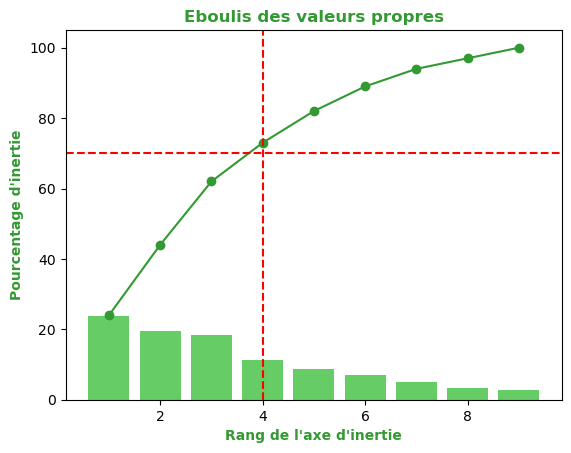

In [20]:
#Graphique des éboulis des valeures propres
plt.bar(x_list, scree, color="#66CC66")
plt.plot(x_list, scree_cum,c="#339933",marker='o')
plt.xlabel("Rang de l'axe d'inertie", weight="bold", color="#339933")
plt.ylabel("Pourcentage d'inertie", weight="bold", color="#339933")
plt.title("Eboulis des valeurs propres", weight="bold", color="#339933")
plt.axhline(y=70, linestyle='dashed', color="red")
plt.axvline(x=4, linestyle='dashed', color="red")

plt.show()

<div>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(102, 204, 102);">
Les 4 premières composantes représentent un peu plus de 70% de la variance
</p>
</div>

In [21]:
#On garde les 4 premières composantess
nb_composante = 4

In [22]:
#Formule de calcul des composantes
pcs = pca.components_
pcs = pcs[pcs.shape[0] - nb_composante:]


In [23]:
#Ajout de la formule de calcul des composants dans un dataframe
pcs = pd.DataFrame(pcs)
pcs

,0,1,2,3,4,5,6,7,8
0,0.683574,0.259278,-0.246928,-0.542155,0.081936,-0.027006,0.083532,0.189146,-0.245760
1,-0.250519,0.202806,0.314064,-0.448863,0.039929,0.593255,-0.419481,0.205616,0.155591
2,-0.081181,-0.117289,-0.216008,-0.027547,0.181718,-0.104325,0.280101,0.664473,0.606917
3,-0.325484,0.104056,0.539273,-0.355805,0.226819,-0.359302,0.473587,0.043179,-0.243159


In [24]:
#Le nom des colonnes est celui des valeurs initiales
pcs.columns = variable_initiales_name
pcs.index = [f"F{i}" for i in range(1, nb_composante + 1)]
pcs.round(2)

,Pourcentage de population urbaine,Croissance annuelle du PIB par habitant en %,PIB par habitant en US$,Stabilité politique,Émissions de CO2 par personne imputables à l'élevage,Densité des poulets dans la superficie agricole par habitant,Part des poulets dans l'élevage en %,Taux de dépendance aux importations de viande de volaille en %,Taux d'autosuffisance en viande de volaille en %
F1,0.68,0.26,-0.25,-0.54,0.08,-0.03,0.08,0.19,-0.25
F2,-0.25,0.20,0.31,-0.45,0.04,0.59,-0.42,0.21,0.16
F3,-0.08,-0.12,-0.22,-0.03,0.18,-0.10,0.28,0.66,0.61
F4,-0.33,0.10,0.54,-0.36,0.23,-0.36,0.47,0.04,-0.24


In [25]:
#Transposition des données
pcs.T

,F1,F2,F3,F4
Pourcentage de population urbaine,0.683574,-0.250519,-0.081181,-0.325484
Croissance annuelle du PIB par habitant en %,0.259278,0.202806,-0.117289,0.104056
PIB par habitant en US$,-0.246928,0.314064,-0.216008,0.539273
Stabilité politique,-0.542155,-0.448863,-0.027547,-0.355805
Émissions de CO2 par personne imputables à l'élevage,0.081936,0.039929,0.181718,0.226819
Densité des poulets dans la superficie agricole par habitant,-0.027006,0.593255,-0.104325,-0.359302
Part des poulets dans l'élevage en %,0.083532,-0.419481,0.280101,0.473587
Taux de dépendance aux importations de viande de volaille en %,0.189146,0.205616,0.664473,0.043179
Taux d'autosuffisance en viande de volaille en %,-0.245760,0.155591,0.606917,-0.243159


<div style="border: 1px solid RGB(102, 204, 102);" >
<h3 style="margin: auto; padding: 20px; color: RGB(102, 204, 102); ">2.2 - Corrélations</h3>
</div>

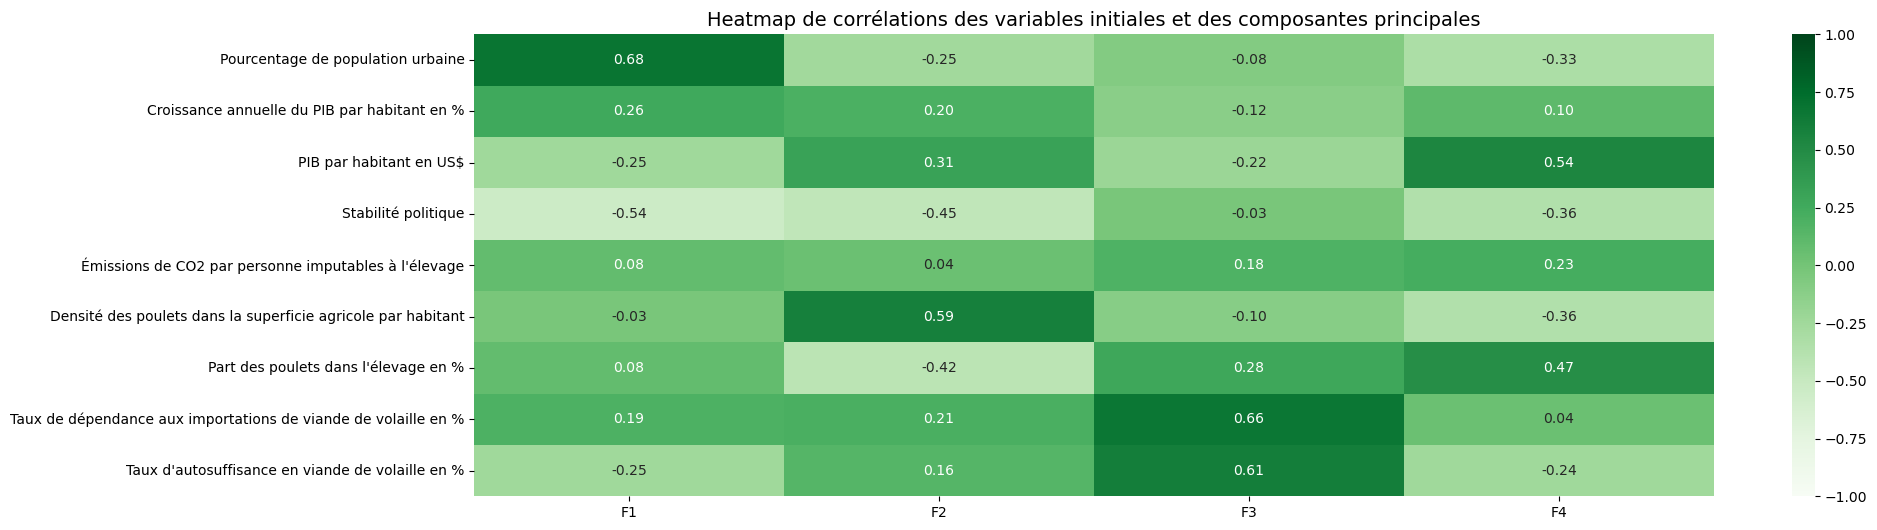

In [26]:
#heatmap représentant le correlation entre les variables initiales et les composantes principales
fig, ax = plt.subplots(figsize=(20, 6))
sns.heatmap(pcs.T, vmin=-1, vmax=1, annot=True, cmap="Greens", fmt="0.2f")

plt.title("Heatmap de corrélations des variables initiales et des composantes principales", size=14)
plt.show()

In [27]:
#Fonction permettant de créer le cercle des corrélations
def correlation_graph(pca,
                      x_y,
                      variable_initiales_name) :
    """Affiche le graphe des correlations

    Positional arguments :
    -----------------------------------
    pca : sklearn.decomposition.PCA : notre objet PCA qui a été fit
    x_y : list ou tuple : le couple x,y des plans à afficher, exemple [0,1] pour F1, F2
    variable_initiales_name : list ou tuple : la liste des variable_initiales_name (ie des dimensions) à représenter
    """

    # Extrait x et y
    x,y=x_y

    # Taille de l'image (en inches)
    fig, ax = plt.subplots(figsize=(15, 14))

    # Pour chaque composante :
    for i in range(0, pca.components_.shape[1]):

        # Les flèches
        ax.arrow(0,0, #Origine du début de la flèche
                pca.components_[x, i], #longueur de la flèche sur l'axe x
                pca.components_[y, i], #longueur de la flèche sur l'axe y
                head_width=0.07, #largeur du bout des flèches
                head_length=0.07, #longeur du bout des flèches
                width=0.02,
                color="#66CC66") #Lageur des flèches

        # Affichage des variables initiales ayant des corrélations supérieures à 0.4 et inférieures à -0.4     
        plt.text(pca.components_[x, i] + 0.05,
                pca.components_[y, i] + 0.05,
                variable_initiales_name[i],
                fontdict={'weight': 'normal', 'size':'14'})
        
    # Affichage des lignes horizontales et verticales
    plt.plot([-1, 1], [0, 0], color='grey', ls='--')
    plt.plot([0, 0], [-1, 1], color='grey', ls='--')


    # Nom des axes, avec le pourcentage d'inertie expliqué
    plt.xlabel('F{} ({}%)'.format(x+1, round(100*pca.explained_variance_ratio_[x],1)), weight="bold", color="#339933")
    plt.ylabel('F{} ({}%)'.format(y+1, round(100*pca.explained_variance_ratio_[y],1)), weight="bold", color="#339933")

    # Titre du graphique
    plt.title("Cercle des corrélations (F{} et F{})".format(x+1, y+1), weight="bold", color="#339933")

    # Le cercle
    an = np.linspace(0, 2 * np.pi, 100)
    plt.plot(np.cos(an), np.sin(an), color="#66CC66")  # Add a unit circle for scale

    # Axes et display
    plt.axis('equal')
    plt.tight_layout()
    plt.show(block=False)

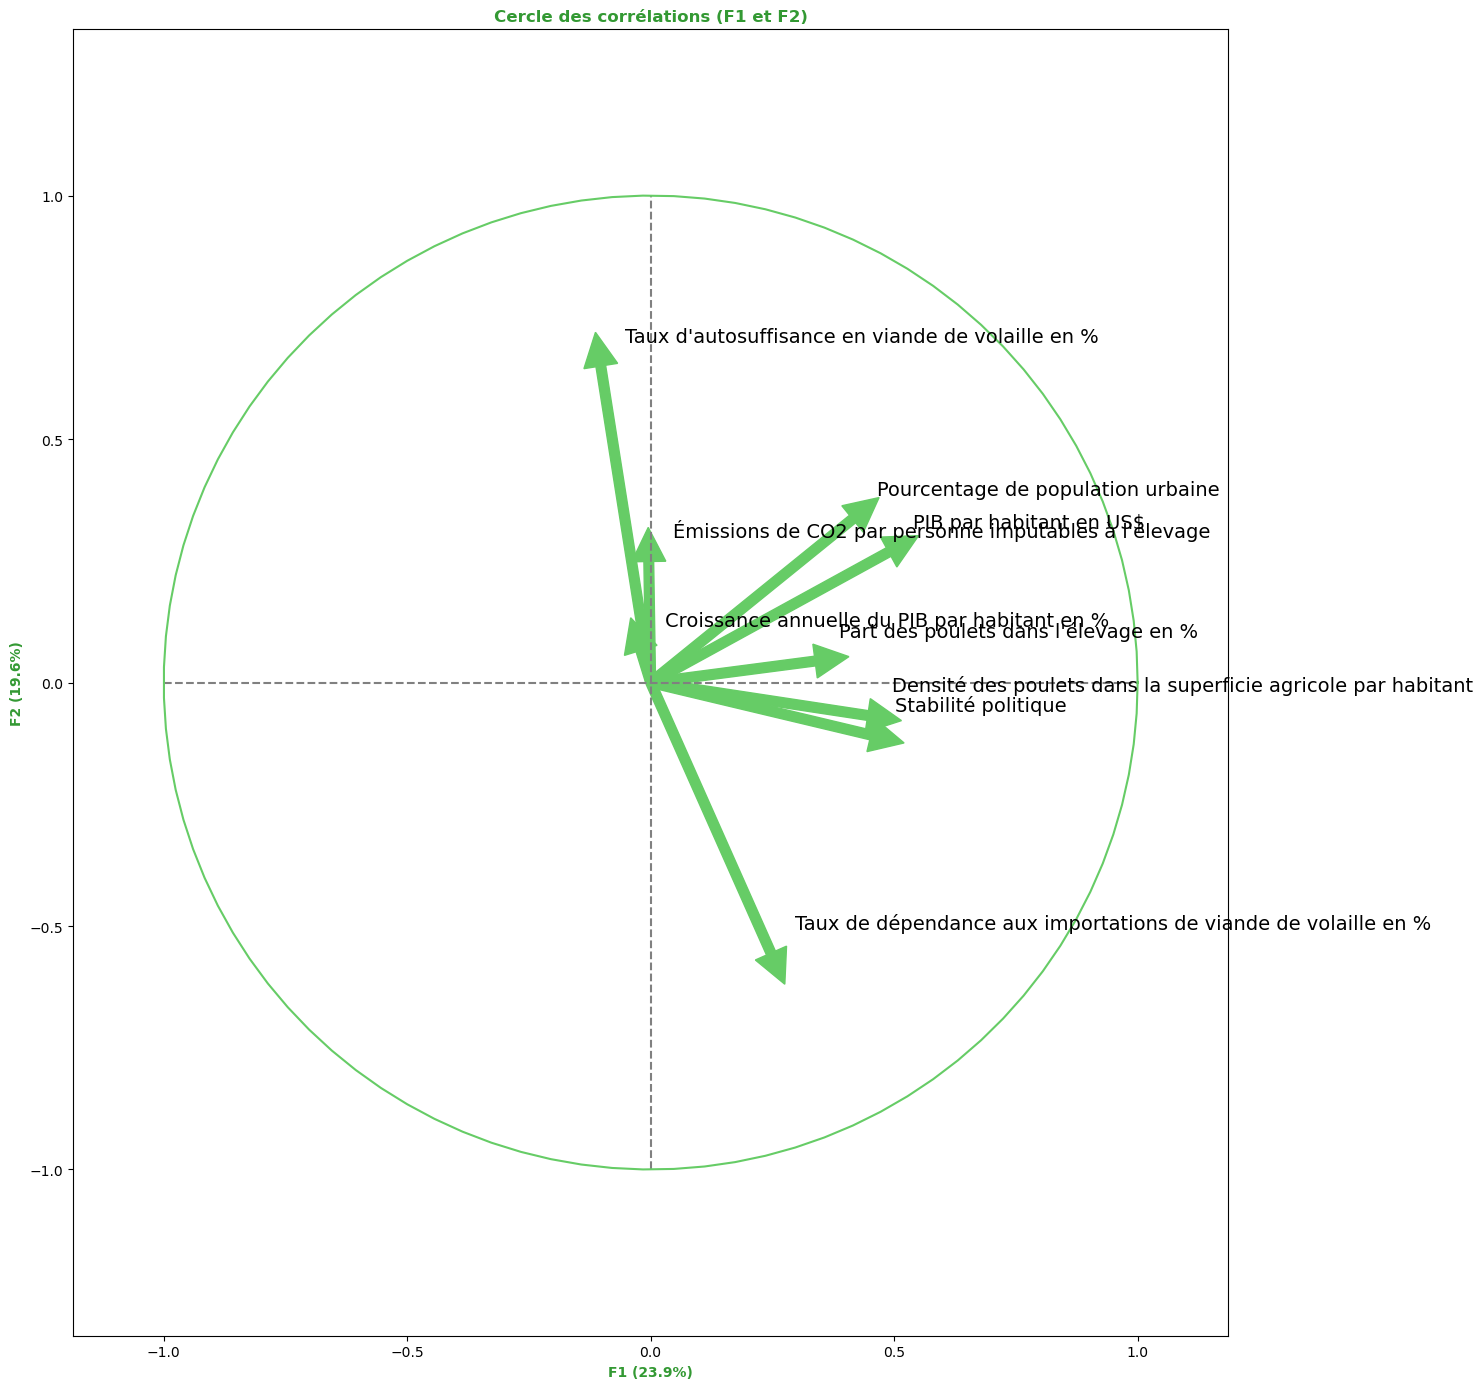

In [28]:
#Cercle de corrélation des composantes F1 et F2
x_y = (0,1)
correlation_graph(pca, x_y, variable_initiales_name)

<div>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(102,204,102);">
    Variables qui influencent F1
    <ul style="color: RGB(102,204,102)">
        <li>Pourcentage de la population urbaine</li>
        <li>PIB par habitant</li>
        <li>Densité des poulets dans la surface agricole</li>
        <li>Stabilité politique</li>
    </ul>
</p>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(102,204,102);">
    Variables qui influencent F2
    <ul style="color: RGB(102,204,102)">
        <li>Taux d'autosuffisance en viande de volaille</li>
        <li>Taux de dépendance aux importations</li>
    </ul>
</p>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(102,204,102);">
F1 réprésente le marché de l'élevage intensif de poulet
<br />
F2 réprésente les pays qui sont en autosuffisance en viande de volaille
</p>
</div>

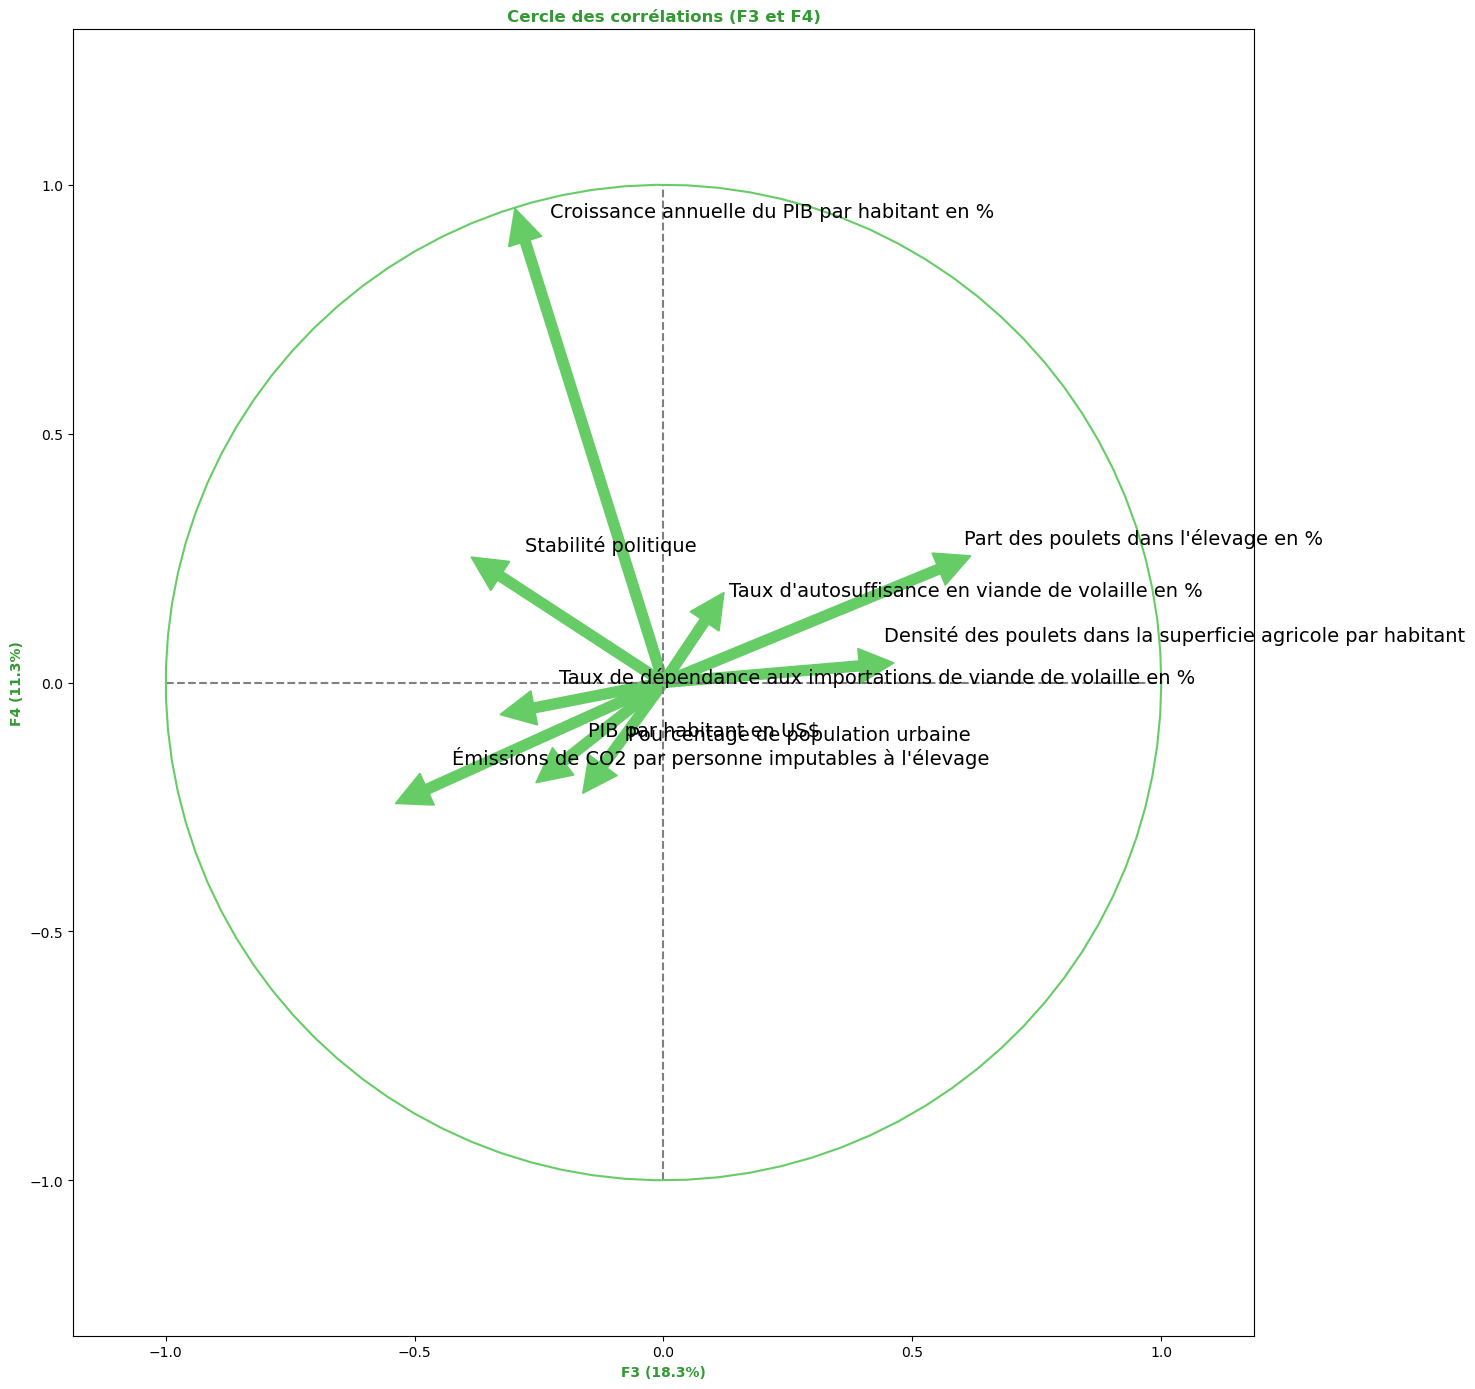

In [29]:
#Cercle de corrélation des composantes F3 et F4
correlation_graph(pca, (2,3), variable_initiales_name)

<div>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(102,204,102);">
    Variables qui influencent F3
    <ul style="color: RGB(102,204,102)">
        <li>Part des poulets dans l'élevage</li>
        <li>Emissions imputables à l'élevage</li>
    </ul>
</p>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(102,204,102);">
    Variables qui influencent F4
    <ul style="color: RGB(102,204,102)">
        <li>Croissance annuelle du PIB par habitant</li>
    </ul>
</p>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(102,204,102);">
F3 réprésente le marché du poulet BIO
<br />
F4 représente les pays économiquement dynamiquues
</p>
</div>

In [30]:
#List contenant le nom des composants
components_names= ['Marché de l\'élevage intensif de poulet', 'Autosuffisance en viande de volaille', 'Marché du poulet BIO', 'Pays économiquement dynamiques']

<div style="border: 1px solid RGB(102, 204, 102);" >
<h3 style="margin: auto; padding: 20px; color: RGB(102, 204, 102); ">2.3 - Projections des données sur les plans factoriels</h3>
</div>

In [31]:
#Projection
X_proj = pca.transform(X_scaled)
X_proj

array([[-2.79304351,  0.12665233,  0.6604822 , ...,  1.56773777,
        -0.2740565 ,  0.61297333],
       [-0.82768651,  0.47220941,  0.59585534, ..., -0.27361252,
        -0.1163154 , -0.49874114],
       [ 0.09291524, -0.97884777, -1.19162504, ...,  0.0687958 ,
        -0.33398202, -0.08581453],
       ...,
       [ 1.45650836,  2.45962408, -0.88069343, ...,  0.73438838,
        -0.92139541,  1.04474511],
       [-2.76923765,  0.64168309, -0.14407328, ...,  1.73991506,
        -0.45863226,  0.70004493],
       [-0.51041157, -2.72789396, -0.40670571, ..., -0.05123846,
         0.11009621,  0.14528342]], shape=(159, 9))

In [32]:
#Projection des pays dans les plans factoriels
def display_factorial_planes(   X_projected,
                                x_y,
                                methode,
                                pca=None,
                                labels = None,
                                clusters=None,
                                centroids_projected = None,
                                components_names = None,
                                alpha=1,
                                figsize=[10,8],
                                marker="." ):
    """
    Affiche la projection des individus

    Positional arguments :
    -------------------------------------
    X_projected : np.array, pd.DataFrame, list of list : la matrice des points projetés
    x_y : list ou tuple : le couple x,y des plans à afficher, exemple [0,1] pour F1, F2

    Optional arguments :
    -------------------------------------
    pca : sklearn.decomposition.PCA : un objet PCA qui a été fit, cela nous permettra d'afficher la variance de chaque composante, default = None
    labels : list ou tuple : les labels des individus à projeter, default = None
    clusters : list ou tuple : la liste des clusters auquel appartient chaque individu, default = None
    alpha : float in [0,1] : paramètre de transparence, 0=100% transparent, 1=0% transparent, default = 1
    figsize : list ou tuple : couple width, height qui définit la taille de la figure en inches, default = [10,8]
    marker : str : le type de marker utilisé pour représenter les individus, points croix etc etc, default = "."
    """

    # Transforme X_projected en np.array
    X_ = np.array(X_projected)

    # On définit la forme de la figure si elle n'a pas été donnée
    if not figsize:
        figsize = (7,6)

    # On gère les labels
    if  labels is None :
        labels = []
    try :
        len(labels)
    except Exception as e :
        raise e

    # On vérifie la variable axis
    if not len(x_y) ==2 :
        raise AttributeError("2 axes sont demandées")
    if max(x_y )>= X_.shape[1] :
        raise AttributeError("la variable axis n'est pas bonne")

    # on définit x et y
    x, y = x_y

    # Initialisation de la figure
    fig, ax = plt.subplots(1, 1, figsize=figsize)

    # On vérifie s'il y a des clusters ou non
    c = None if clusters is None else clusters

    # On vérifie s'il y a des centroides ou non
    centroids_proj = None if centroids_projected is None else np.array(centroids_projected)

    # Les points
    if clusters is not None:
        sns.scatterplot(data=None, x=X_[:, x], y=X_[:, y], hue=c, palette="Set1")
        #Titre de la légende
        plt.legend(title = "Cluster")
    else:
        sns.scatterplot(data=None, x=X_[:, x], y=X_[:, y], hue=c, color="#339933")

    if centroids_proj is not None:
        sns.scatterplot(data=None, x=centroids_proj[:, x], y=centroids_proj[:, y],  marker="s", c="black" )
    
    #Titre de la légende    
    if clusters is not None:

        plt.legend(title = "Cluster")

    # Si la variable pca a été fournie, on peut calculer le % de variance de chaque axe
    if pca :
        v1 = str(round(100*pca.explained_variance_ratio_[x]))  + " %"
        v2 = str(round(100*pca.explained_variance_ratio_[y]))  + " %"
    else :
        v1=v2= ''

    # Nom des axes, avec le pourcentage d'inertie expliqué
    ax.set_xlabel(f'F{x+1} {v1} : '+components_names[x], weight="bold", color="#339933")
    ax.set_ylabel(f'F{y+1} {v2} : '+components_names[y], weight="bold", color="#339933")

    # Valeur x max et y max
    x_max = np.abs(X_[:, x]).max() *1.1
    y_max = np.abs(X_[:, y]).max() *1.1

    # On borne x et y
    ax.set_xlim(left=-x_max, right=x_max)
    ax.set_ylim(bottom= -y_max, top=y_max)

    # Affichage des lignes horizontales et verticales
    plt.plot([-x_max, x_max], [0, 0], color='grey', alpha=0.8)
    plt.plot([0,0], [-y_max, y_max], color='grey', alpha=0.8)

    # Affichage des labels des points
    if len(labels) :
        for i,(_x,_y) in enumerate(X_[:,[x,y]]):
            plt.text(_x, _y+0.05, labels[i], fontsize='14', ha='center',va='center')


    
    # Titre et display
    plt.title(f"Projection des pays sur F{x+1} et F{y+1} ({methode})", weight="bold", color="#339933")
    plt.show()



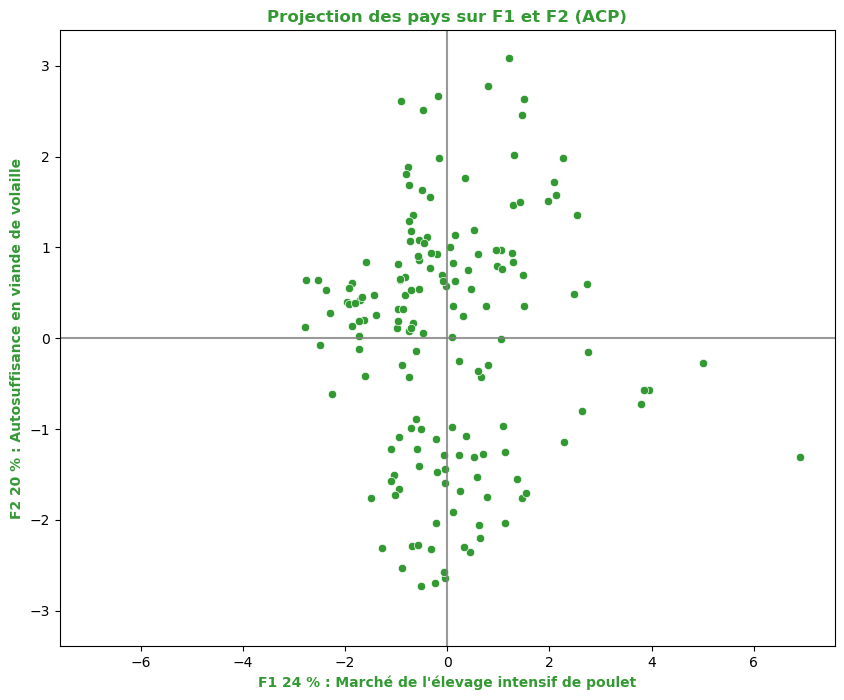

In [33]:
#Projection des pays dans le 1er plan factoriel
x_y = [0,1]
display_factorial_planes(X_proj, x_y, "ACP", pca, components_names=components_names)

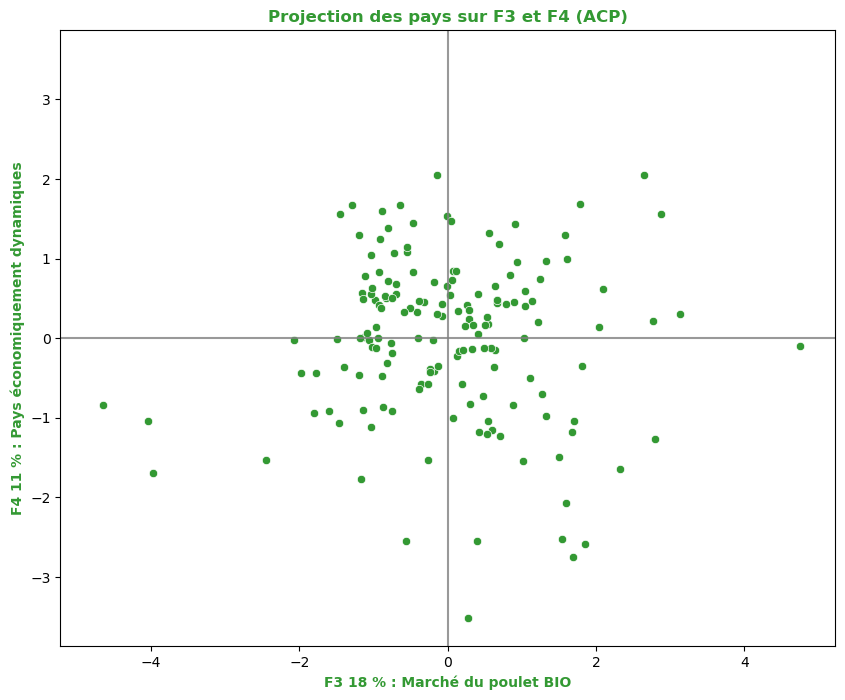

In [34]:
#Projection des pays dans le 2eme plan factoriel
x_y = [2,3]
display_factorial_planes(X_proj, x_y, "ACP", pca, components_names=components_names)

<div style="border: 1px solid RGB(102, 204, 102);" >
<h3 style="margin: auto; padding: 20px; color: RGB(102, 204, 102); ">2.4 - Ajout de la valeur des composantes principales au dataframe original</h3>
</div>

In [35]:
#Ajout des composantes dans la dataframe inital
idx = 0
composante_name_in_df_list = []
for composante in pcs.T.columns:
    variable_value = 0
    for var_init in pcs.T[composante].index:
        variable_value += df_chicken_data[var_init] * pcs.T[composante][var_init]
    composante_name_in_df = composante + ' : ' + components_names[idx]   
    df_chicken_data[composante_name_in_df] = variable_value
    composante_name_in_df_list.append(composante_name_in_df)
    idx = idx + 1
        
df_chicken_data.head()

,Pourcentage de population urbaine,Croissance annuelle du PIB par habitant en %,PIB par habitant en US$,Stabilité politique,Émissions de CO2 par personne imputables à l'élevage,Densité des poulets dans la superficie agricole par habitant,Part des poulets dans l'élevage en %,Taux de dépendance aux importations de viande de volaille en %,Taux d'autosuffisance en viande de volaille en %,F1 : Marché de l'élevage intensif de poulet,F2 : Autosuffisance en viande de volaille,F3 : Marché du poulet BIO,F4 : Pays économiquement dynamiques
Pays,,,,,,,,,,,,,
Afghanistan,26.409644,13.367738,396.015997,-2.484081,0.36,0.00,1.91,14.705882,85.294118,-92.913176,137.092265,-27.047619,188.120738
Afrique du Sud,65.986638,-8.012762,5976.385898,-0.665642,0.37,0.02,12.19,15.330848,86.999068,-1449.781571,1870.712324,-1228.879934,3186.184687
Albanie,67.720435,22.158933,8172.294966,0.183349,0.67,0.05,10.69,74.285714,25.714286,-1957.354892,2568.917581,-1705.307094,4389.446163
Algérie,73.661062,8.111885,5364.027937,-0.577885,0.28,0.05,27.24,0.000000,100.438596,-1294.147549,1672.340752,-1096.956435,2858.271838
Allemagne,75.933325,8.103028,53528.073268,0.586989,0.49,0.09,9.13,51.525199,101.525199,-13178.309921,16816.232822,-11471.147481,28824.091454


<div style="background-color: RGB(102, 204, 102);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Clustering</h2>
</div>

<div style="border: 1px solid RGB(102, 204, 102);" >
<h3 style="margin: auto; padding: 20px; color: RGB(102, 204, 102); ">3.1 - Classification ascendante hiérarchique</h3>
</div>

In [36]:
#Calcul des distances avec la méthode de ward
Z = linkage(X_scaled, method="ward")
Z[:10]

array([[ 59.        ,  79.        ,   0.36094548,   2.        ],
       [  3.        ,  82.        ,   0.4356778 ,   2.        ],
       [  1.        ,  11.        ,   0.44190989,   2.        ],
       [  6.        , 121.        ,   0.46599128,   2.        ],
       [ 45.        , 112.        ,   0.4850241 ,   2.        ],
       [ 81.        ,  98.        ,   0.49635716,   2.        ],
       [139.        , 147.        ,   0.51376637,   2.        ],
       [ 57.        , 134.        ,   0.53699039,   2.        ],
       [ 78.        ,  88.        ,   0.55206515,   2.        ],
       [ 52.        ,  69.        ,   0.58347086,   2.        ]])

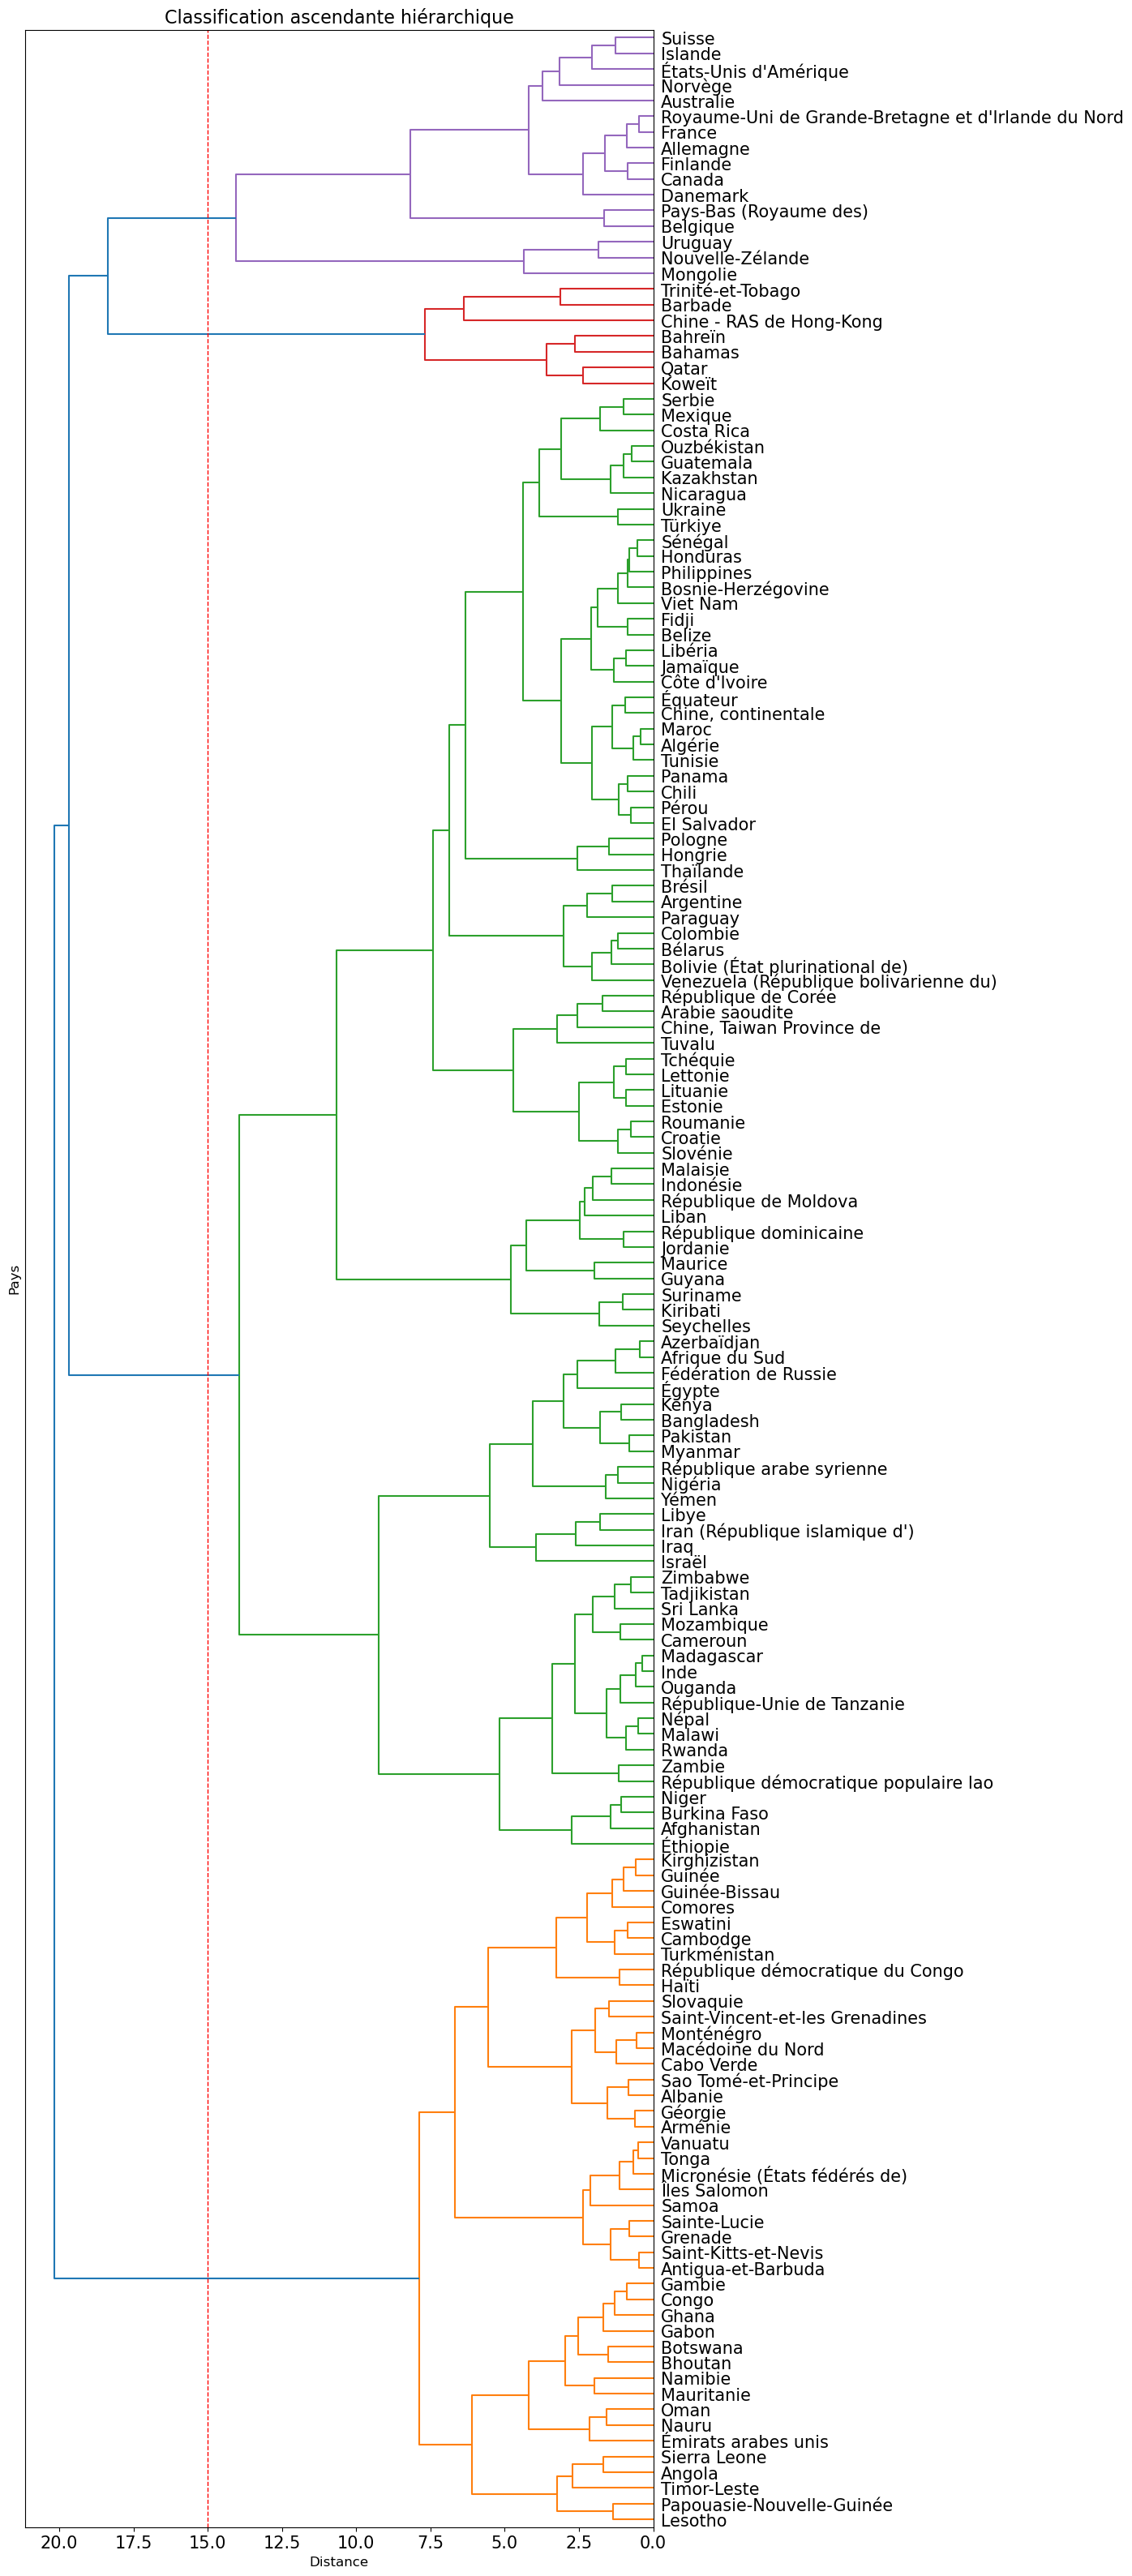

In [37]:
#Affichage du dendrogrammme
fig, ax = plt.subplots(1, 1, figsize=(10,40))

_ = dendrogram(Z, ax=ax, labels=nom_pays, orientation = "left")



plt.title("Classification ascendante hiérarchique", fontsize=16)
ax.set_xlabel("Distance", fontsize=12)
ax.set_ylabel("Pays", fontsize=12)
ax.tick_params(axis='x', which='major', labelsize=15)
ax.tick_params(axis='y', which='major', labelsize=15)
ax.axvline(x=15, lw=1, linestyle='dashed', color="red")
plt.show()


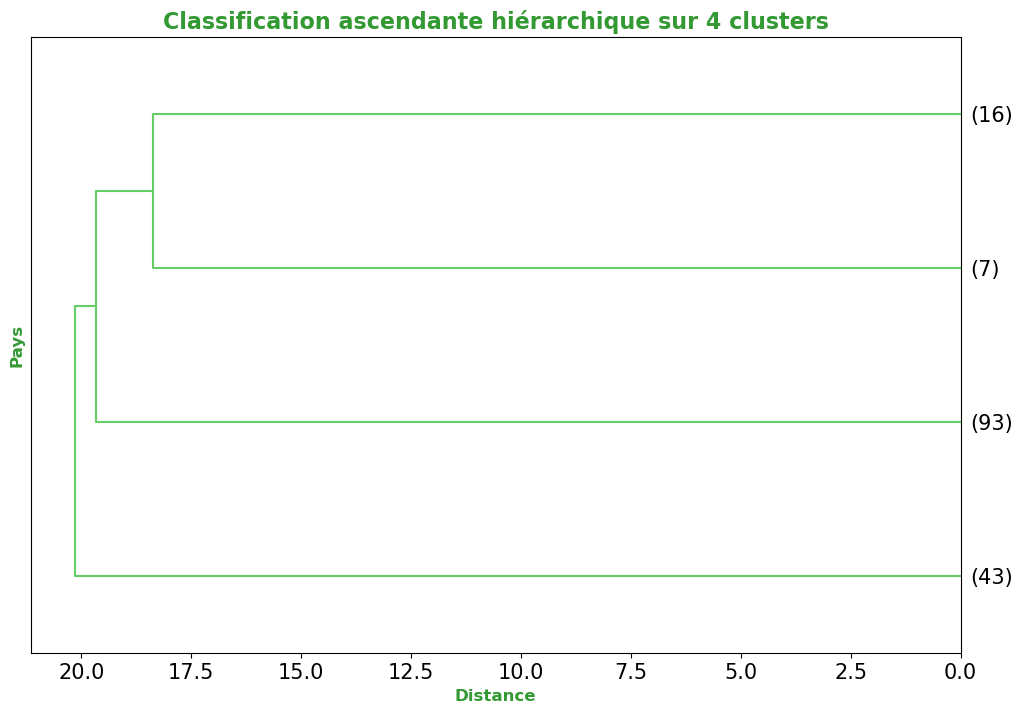

In [38]:
#Dendrogramme avec 4 clusters
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

_ = dendrogram(Z,  ax=ax, labels=nom_pays, orientation = "left",  p=4, truncate_mode="lastp", above_threshold_color='#66CC66')

plt.title("Classification ascendante hiérarchique sur 4 clusters", fontsize=16, color="#339933", weight="bold")
ax.set_xlabel("Distance", fontsize=12, weight='bold', color="#339933")
ax.set_ylabel("Pays", fontsize=12, weight='bold', color="#339933")
ax.tick_params(axis='x', which='major', labelsize=15)
ax.tick_params(axis='y', which='major', labelsize=15)

plt.show()

<div style="border: 1px solid RGB(102, 204, 102);" >
<h3 style="margin: auto; padding: 20px; color: RGB(102, 204, 102); ">3.2 - Correspondance pays et clusters</h3>
</div>

In [39]:
nb_cluster=4

In [40]:
clusters = fcluster(Z, nb_cluster, criterion='maxclust')
clusters

array([2, 2, 1, 2, 4, 1, 1, 2, 2, 1, 4, 2, 3, 3, 2, 3, 4, 2, 1, 2, 2, 1,
       2, 2, 2, 1, 1, 2, 4, 2, 3, 2, 2, 2, 1, 1, 2, 2, 2, 4, 2, 2, 1, 2,
       4, 4, 2, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 2, 2, 2, 2, 2, 2, 4, 2, 2,
       2, 2, 2, 1, 2, 3, 1, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 1, 2, 1, 4,
       1, 2, 2, 1, 1, 2, 2, 2, 4, 4, 2, 1, 2, 2, 2, 2, 1, 2, 4, 2, 2, 2,
       3, 2, 4, 2, 2, 2, 2, 2, 1, 2, 2, 1, 1, 1, 1, 1, 2, 2, 1, 1, 2, 2,
       4, 2, 2, 2, 2, 2, 1, 1, 3, 2, 1, 2, 2, 2, 4, 1, 2, 2, 2, 2, 2, 2,
       1, 2, 4, 2, 1], dtype=int32)

In [41]:
# correspondance pays avec le cluster
df_pays_cluster = pd.DataFrame({"pays" : nom_pays, "cluster" : clusters})
df_pays_cluster.head()

,pays,cluster
0,Afghanistan,2
1,Afrique du Sud,2
2,Albanie,1
3,Algérie,2
4,Allemagne,4


In [42]:
#Affichage des pays par cluster
for i in range(1, nb_cluster + 1) :
    # on fait une selection
    sub_df = df_pays_cluster.loc[df_pays_cluster.cluster == i]

    # le cluster en question
    print(f"cluster : {i}")

    # on extrait les noms et les themes de chaque ligne
    names_list = sub_df.pays.values

    # on créé une liste de couple nom/theme

    txt = [f"{n}" for n in names_list]

    # on transforme en str
    txt = " / ".join(txt)

    # on print
    print(txt)
    print("\n")

cluster : 1
Albanie / Angola / Antigua-et-Barbuda / Arménie / Bhoutan / Botswana / Cabo Verde / Cambodge / Comores / Congo / Eswatini / Gabon / Gambie / Ghana / Grenade / Guinée / Guinée-Bissau / Géorgie / Haïti / Kirghizistan / Lesotho / Macédoine du Nord / Mauritanie / Micronésie (États fédérés de) / Monténégro / Namibie / Nauru / Oman / Papouasie-Nouvelle-Guinée / République démocratique du Congo / Saint-Kitts-et-Nevis / Saint-Vincent-et-les Grenadines / Sainte-Lucie / Samoa / Sao Tomé-et-Principe / Sierra Leone / Slovaquie / Timor-Leste / Tonga / Turkménistan / Vanuatu / Émirats arabes unis / Îles Salomon


cluster : 2
Afghanistan / Afrique du Sud / Algérie / Arabie saoudite / Argentine / Azerbaïdjan / Bangladesh / Belize / Bolivie (État plurinational de) / Bosnie-Herzégovine / Brésil / Burkina Faso / Bélarus / Cameroun / Chili / Chine, Taiwan Province de / Chine, continentale / Colombie / Costa Rica / Croatie / Côte d'Ivoire / El Salvador / Estonie / Fidji / Fédération de Russie /

In [43]:
#Ajout du cluster dans le dataframe initial
df_chicken_data["cluster_dendrogram"] = clusters
df_chicken_data.head()

,Pourcentage de population urbaine,Croissance annuelle du PIB par habitant en %,PIB par habitant en US$,Stabilité politique,Émissions de CO2 par personne imputables à l'élevage,Densité des poulets dans la superficie agricole par habitant,Part des poulets dans l'élevage en %,Taux de dépendance aux importations de viande de volaille en %,Taux d'autosuffisance en viande de volaille en %,F1 : Marché de l'élevage intensif de poulet,F2 : Autosuffisance en viande de volaille,F3 : Marché du poulet BIO,F4 : Pays économiquement dynamiques,cluster_dendrogram
Pays,,,,,,,,,,,,,,
Afghanistan,26.409644,13.367738,396.015997,-2.484081,0.36,0.00,1.91,14.705882,85.294118,-92.913176,137.092265,-27.047619,188.120738,2
Afrique du Sud,65.986638,-8.012762,5976.385898,-0.665642,0.37,0.02,12.19,15.330848,86.999068,-1449.781571,1870.712324,-1228.879934,3186.184687,2
Albanie,67.720435,22.158933,8172.294966,0.183349,0.67,0.05,10.69,74.285714,25.714286,-1957.354892,2568.917581,-1705.307094,4389.446163,1
Algérie,73.661062,8.111885,5364.027937,-0.577885,0.28,0.05,27.24,0.000000,100.438596,-1294.147549,1672.340752,-1096.956435,2858.271838,2
Allemagne,75.933325,8.103028,53528.073268,0.586989,0.49,0.09,9.13,51.525199,101.525199,-13178.309921,16816.232822,-11471.147481,28824.091454,4


<div style="border: 1px solid RGB(102, 204, 102);" >
<h3 style="margin: auto; padding: 20px; color: RGB(102, 204, 102); ">3.3 - Projections des clusters sur les plans factoriels</h3>
</div>

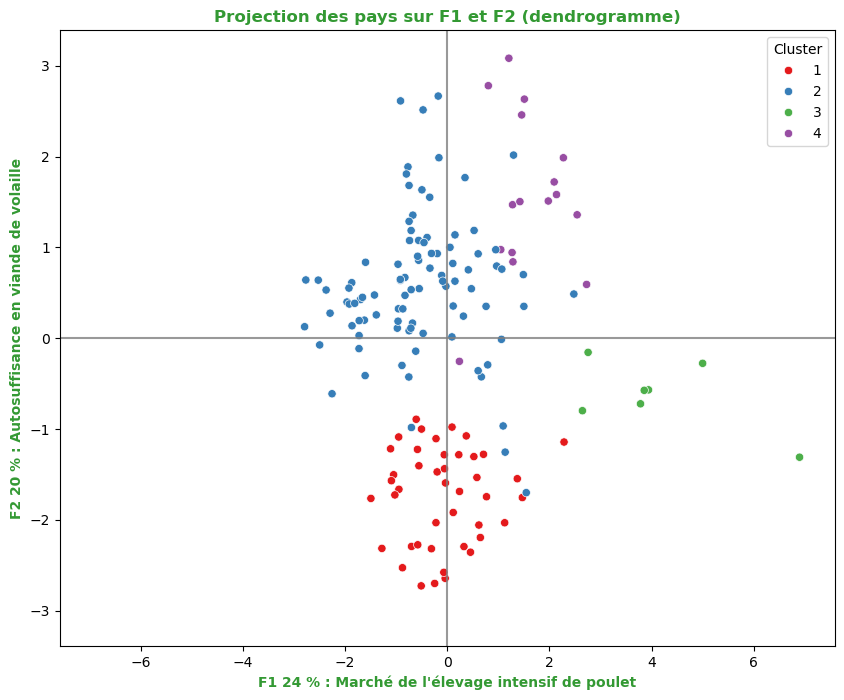

In [44]:
#Projection des clusters de pays dans le 1er plan factoriel
x_y = [0,1]
display_factorial_planes(X_proj, x_y, "dendrogramme", pca, components_names=components_names, clusters=clusters)

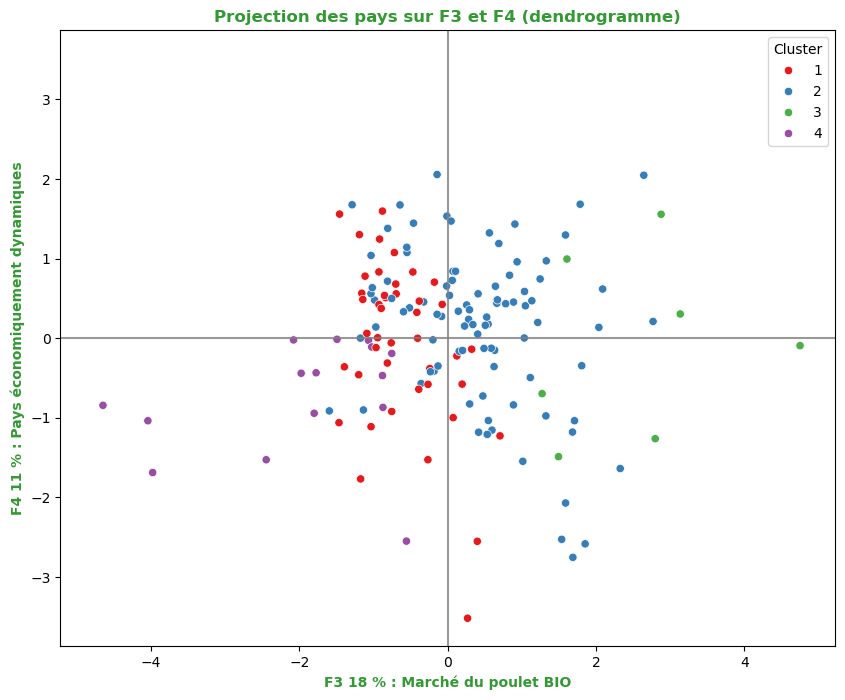

In [45]:
#Projection des clusters de pays dans le 2eme plan factoriel
x_y = [2,3]
display_factorial_planes(X_proj, x_y, "dendrogramme", pca, components_names=components_names, clusters=clusters)

<div>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(102,204,102);">
    <ul style="color: RGB(102,204,102)">
        <li>Le cluster 1 représente les pays dépendant de l'importation de viande de volaille et faisant peu d’élevage de poulet BIO</li>
        <li>Le cluster 2 représente plusieurs type de pays</li>
        <li>Le cluster 3 représente les pays faisant de l’élevage de intensif de poulet BIO et dépendant des importations</li>
        <li>Le cluster 4 représente les pays autosuffisants faisant de l’élevage de intensif de poulet et non dynamique économiquement</li>
    </ul>
</p>
</div>

<div style="border: 1px solid RGB(102, 204, 102);" >
<h3 style="margin: auto; padding: 20px; color: RGB(102, 204, 102); ">3.4 - k-means</h3>
</div>

In [46]:
# Une liste vide pour enregistrer les inerties :  
intertia_list = [ ]

# Notre liste de nombres de clusters : 
k_list = range(1, 10)

# Pour chaque nombre de clusters : 
for k in k_list : 
    
    # On instancie un k-means pour k clusters
    kmeans = KMeans(n_clusters=k)
    
    # On entraine
    kmeans.fit(X)
    
    # On enregistre l'inertie obtenue : 
    intertia_list.append(kmeans.inertia_)

c:\Users\ndiem\anaconda4\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ndiem\anaconda4\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ndiem\anaconda4\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ndiem\anaconda4\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

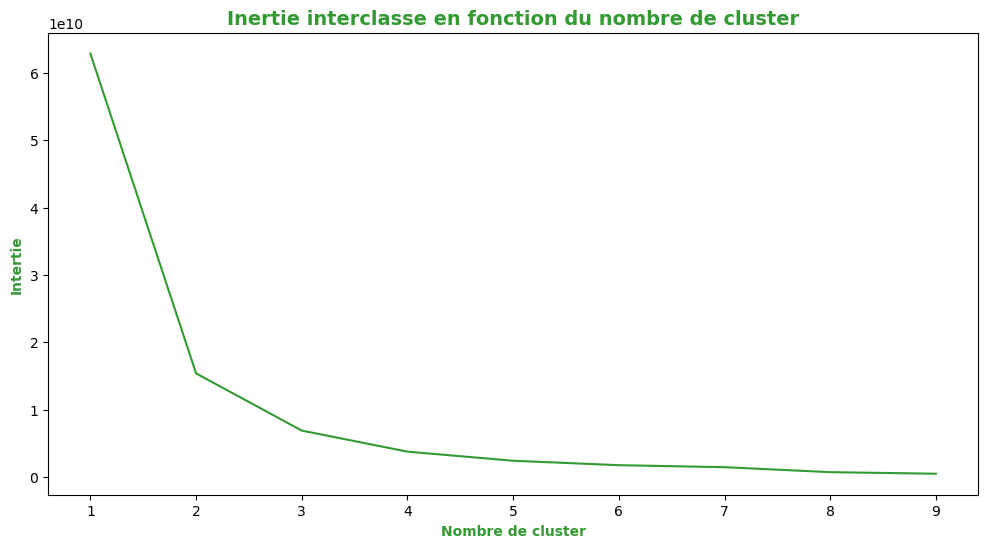

In [47]:
fig, ax = plt.subplots(1,1,figsize=(12,6))

ax.set_ylabel("Intertie", weight='bold', color="#339933")
ax.set_xlabel("Nombre de cluster", weight='bold', color="#339933")

ax = plt.plot(k_list, intertia_list, color="#339933")

plt.title("Inertie interclasse en fonction du nombre de cluster", fontsize=14, weight='bold', color="#339933")
plt.show()

<div>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(102,204,102);">
    Avec la méthode k-mean on constate que la dernière cassure est de 3 et à partir de 4 clusters il y a un plat.
    <br/>
    Donc nous choississons 4 clusters
</p>
</div>

In [48]:
#Projection des pays dans les plans factoriels
def display_factorial_planes_with_centroids(nb_cluster,
                                X_scaled,
                                X_proj,
                                pca,
                                components_names):
    
    # On instancie notre Kmeans avec "nb_cluster" clusters : 
    kmeans = KMeans(n_clusters=nb_cluster, random_state=42)

    # On l'entraine : 
    kmeans.fit(X_scaled)

    # On peut stocker nos centroids dans une variable : 
    centroids = kmeans.cluster_centers_

    # On utilise bien le scaler déjà entrainé : 
    centroids_scaled = centroids

    # et on utilise l'ACP déjà entrainée : 
    centroids_proj = pca.transform(centroids_scaled)

    #Ajout des clusters dans la dataframe initial
    clusters_kmean = kmeans.labels_
    df_chicken_data[f"cluster_{nb_cluster}_kmeans"] = clusters_kmean

    #Projection des pays dans le 1er plan factoriel avec nb_cluster clusters
    display_factorial_planes(X_proj, [0,1], f"k-means : {nb_cluster} clusters", pca, clusters=clusters_kmean,  components_names = components_names, centroids_projected=centroids_proj)

    #Projection des pays dans le 2ème plan factoriel avec nb_cluster clusters
    display_factorial_planes(X_proj, [2,3], f"k-means : {nb_cluster} clusters", pca, clusters=clusters_kmean,  components_names = components_names, centroids_projected=centroids_proj)


<div style="border: 1px solid RGB(102, 204, 102);" >
<h3 style="margin: auto; padding: 20px; color: RGB(102, 204, 102); ">3.2.1 - k-means à 4 clusters</h3>
</div>

c:\Users\ndiem\anaconda4\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


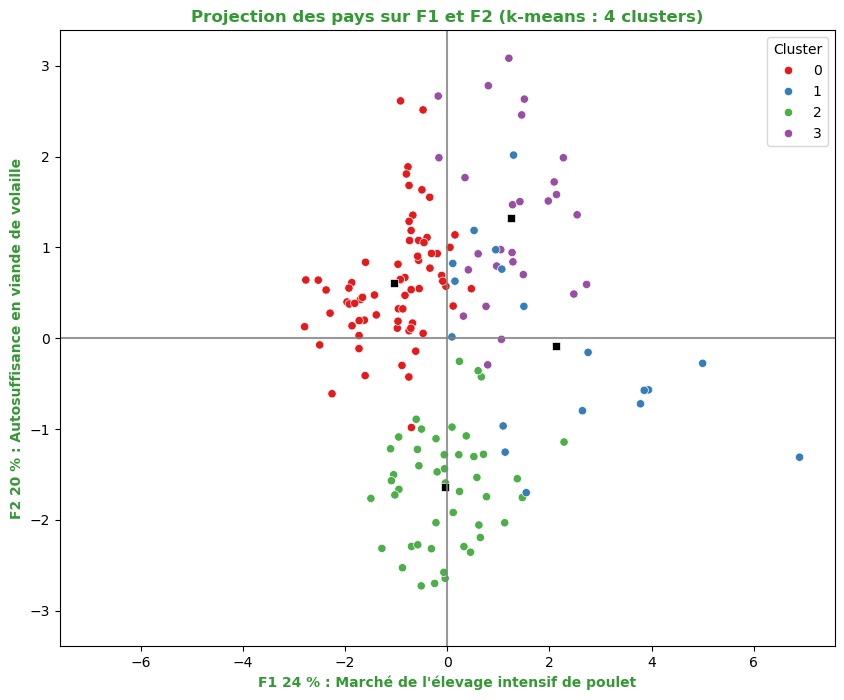

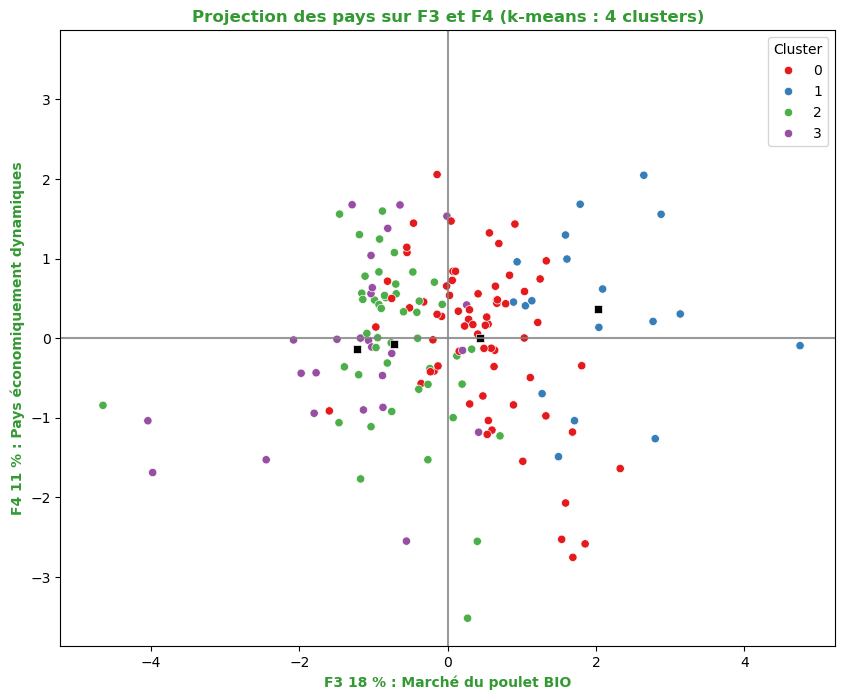

In [49]:
display_factorial_planes_with_centroids(4, X_scaled, X_proj, pca, components_names)

<div>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(102,204,102);">
    <ul style="color: RGB(102,204,102)">
        <li>Le cluster 0 représente les pays faisant peu d’élevage de poulet</li>
        <li>Le cluster 1 représente les pays faisant de l’élevage intensif de poulet BIO</li>
        <li>Le cluster 2 représente les pays dépendants des importations faisant peu d’élevage de poulet BIO</li>
        <li>Le cluster 3 représente les pays faisant de l’élevage intensif de poulet non BIO </li>
    </ul>
</p>
</div>

<div style="background-color: RGB(102, 204, 102);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Comparaison des clusters du dendrogramme et du k-means</h2>
</div>

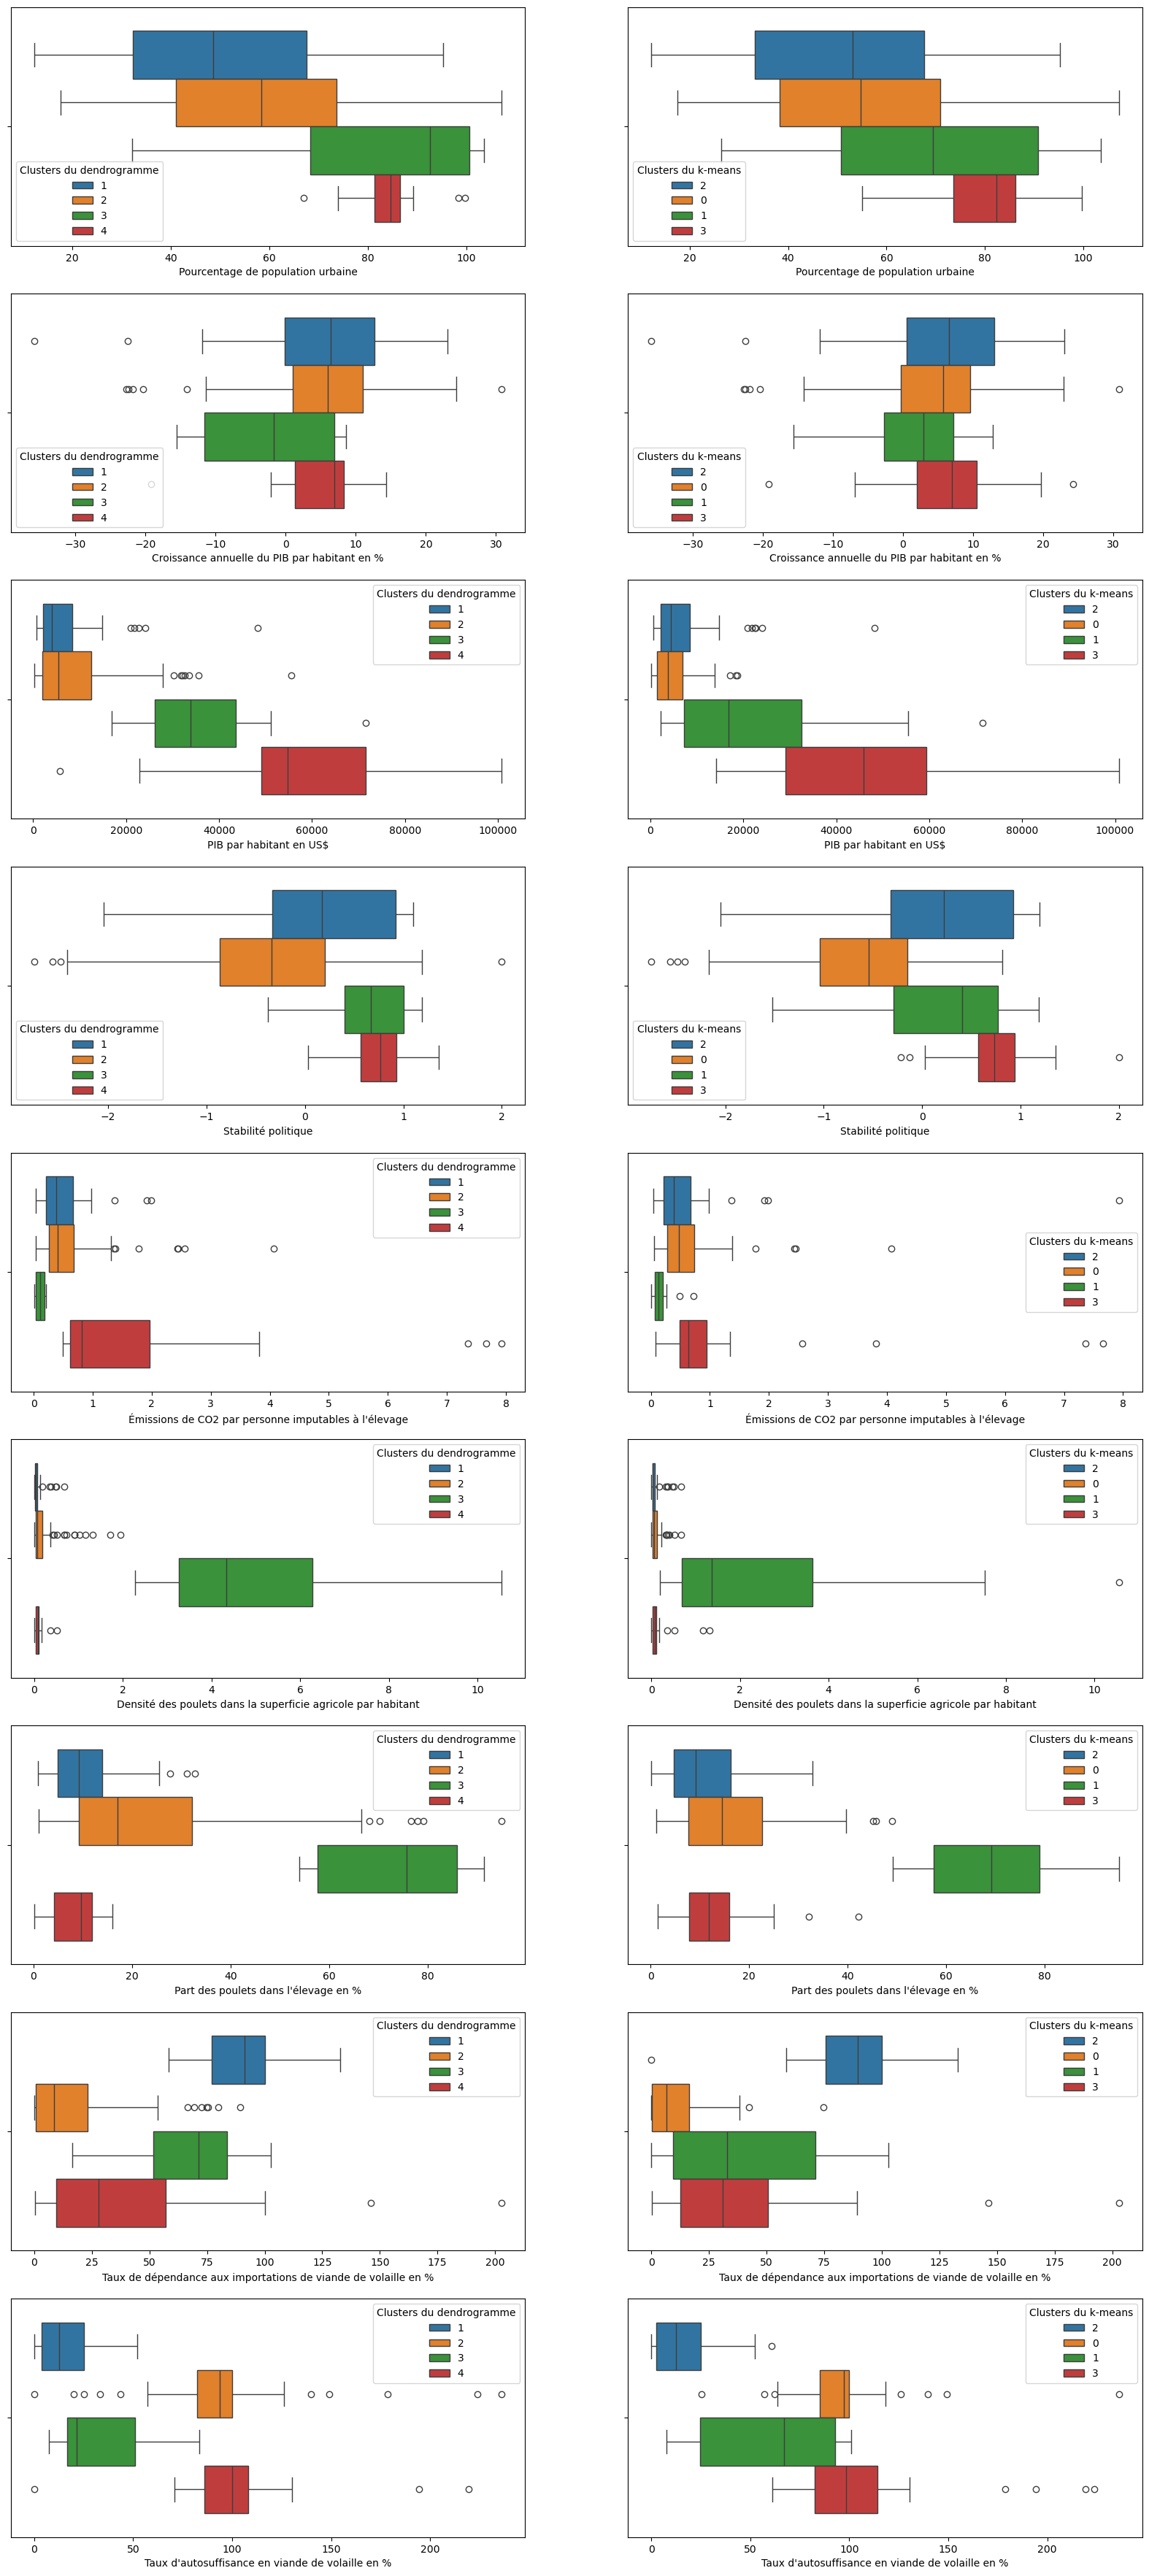

In [50]:
#boxplot des variables initiales de chaque cluster
fig, axes = plt.subplots(len(variable_initiales_name),2)
fig.set_size_inches(20, 45)

for i, variable_initiales in enumerate(variable_initiales_name):
    sns.boxplot(data=df_chicken_data, x=variable_initiales, hue="cluster_dendrogram", ax=axes[i, 0], palette="tab10").legend(title="Clusters du dendrogramme")
    sns.boxplot(data=df_chicken_data, x=variable_initiales, hue="cluster_4_kmeans", hue_order=[2, 0, 1, 3],ax=axes[i, 1], palette="tab10").legend(title="Clusters du k-means")

plt.show()

<div>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(102,204,102);">
Dendrogramme
    <ul style="color: RGB(102,204,102)">
        <li>Le cluster 1 représente les pays émergents dépendant des importations de viande de volaille</li>
        <li>Le cluster 2 représente les pays émergents autosuffisants en viande de volaille</li>
        <li>Le cluster 3 représente les pays industrialisés faisant l'élevage de poulet intensif BIO qui dépend de l'importation de la viande de volaille</li>
        <li>Le cluster 4 représente les pays industrialisés ayant un PIB très élevé qui sont autosuffisant en viande de volaille </li>
    </ul>
</p>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(102,204,102);">
    K-means
    <ul style="color: RGB(102,204,102)">
        <li>Le cluster 0 représente les pays émergents autosuffisants en viande de volaille</li>
        <li>Le cluster 1 représente les pays industrialisés faisant l'élevage de poulet intensif BIO</li>
        <li>Le cluster 2 représente les pays émergents dépendant des importations de viande de volaille</li>
        <li>Le cluster 3 représente les pays industrialisés ayant un PIB très élevé qui sont autosuffisant en viande de volaille </li>
    </ul>
</p>
</div>

<div style="border: 1px solid RGB(102, 204, 102);" >
<h3 style="margin: auto; padding: 20px; color: RGB(102, 204, 102); ">5.1 - Comparaison du cluster 1 du dendrogramme et du cluster 2 du k-means</h3>
</div>

In [51]:
pays_cluster_1_dendrogramme = df_chicken_data[df_chicken_data['cluster_dendrogram'] == 1].index

print("Nombre de pays du cluster 1 du dendrogramme", pays_cluster_1_dendrogramme.shape[0])
pays_cluster_1_dendrogramme

Nombre de pays du cluster 1 du dendrogramme 43


Index(['Albanie', 'Angola', 'Antigua-et-Barbuda', 'Arménie', 'Bhoutan',
       'Botswana', 'Cabo Verde', 'Cambodge', 'Comores', 'Congo', 'Eswatini',
       'Gabon', 'Gambie', 'Ghana', 'Grenade', 'Guinée', 'Guinée-Bissau',
       'Géorgie', 'Haïti', 'Kirghizistan', 'Lesotho', 'Macédoine du Nord',
       'Mauritanie', 'Micronésie (États fédérés de)', 'Monténégro', 'Namibie',
       'Nauru', 'Oman', 'Papouasie-Nouvelle-Guinée',
       'République démocratique du Congo', 'Saint-Kitts-et-Nevis',
       'Saint-Vincent-et-les Grenadines', 'Sainte-Lucie', 'Samoa',
       'Sao Tomé-et-Principe', 'Sierra Leone', 'Slovaquie', 'Timor-Leste',
       'Tonga', 'Turkménistan', 'Vanuatu', 'Émirats arabes unis',
       'Îles Salomon'],
      dtype='object', name='Pays')

In [52]:
pays_cluster_2_kmeans = df_chicken_data[df_chicken_data['cluster_4_kmeans'] == 2].index

print("Nombre de pays du cluster 2 du kmean", pays_cluster_2_kmeans.shape[0])
pays_cluster_2_kmeans

Nombre de pays du cluster 2 du kmean 46


Index(['Albanie', 'Angola', 'Antigua-et-Barbuda', 'Arménie', 'Bhoutan',
       'Botswana', 'Cabo Verde', 'Cambodge', 'Comores', 'Congo', 'Eswatini',
       'Gabon', 'Gambie', 'Ghana', 'Grenade', 'Guinée', 'Guinée-Bissau',
       'Géorgie', 'Haïti', 'Kirghizistan', 'Lesotho', 'Lettonie',
       'Macédoine du Nord', 'Mauritanie', 'Micronésie (États fédérés de)',
       'Mongolie', 'Monténégro', 'Namibie', 'Nauru', 'Oman',
       'Papouasie-Nouvelle-Guinée', 'République démocratique du Congo',
       'Saint-Kitts-et-Nevis', 'Saint-Vincent-et-les Grenadines',
       'Sainte-Lucie', 'Samoa', 'Sao Tomé-et-Principe', 'Sierra Leone',
       'Slovaquie', 'Timor-Leste', 'Tonga', 'Turkménistan', 'Tuvalu',
       'Vanuatu', 'Émirats arabes unis', 'Îles Salomon'],
      dtype='object', name='Pays')

In [53]:
print("Pays se trouvant dans le cluster 2 du kmean et ne se trouvant pas dans le cluster 1 du dendrogramme")
pays_cluster_2_kmeans[~pays_cluster_2_kmeans.isin(pays_cluster_1_dendrogramme)]


Pays se trouvant dans le cluster 2 du kmean et ne se trouvant pas dans le cluster 1 du dendrogramme


Index(['Lettonie', 'Mongolie', 'Tuvalu'], dtype='object', name='Pays')

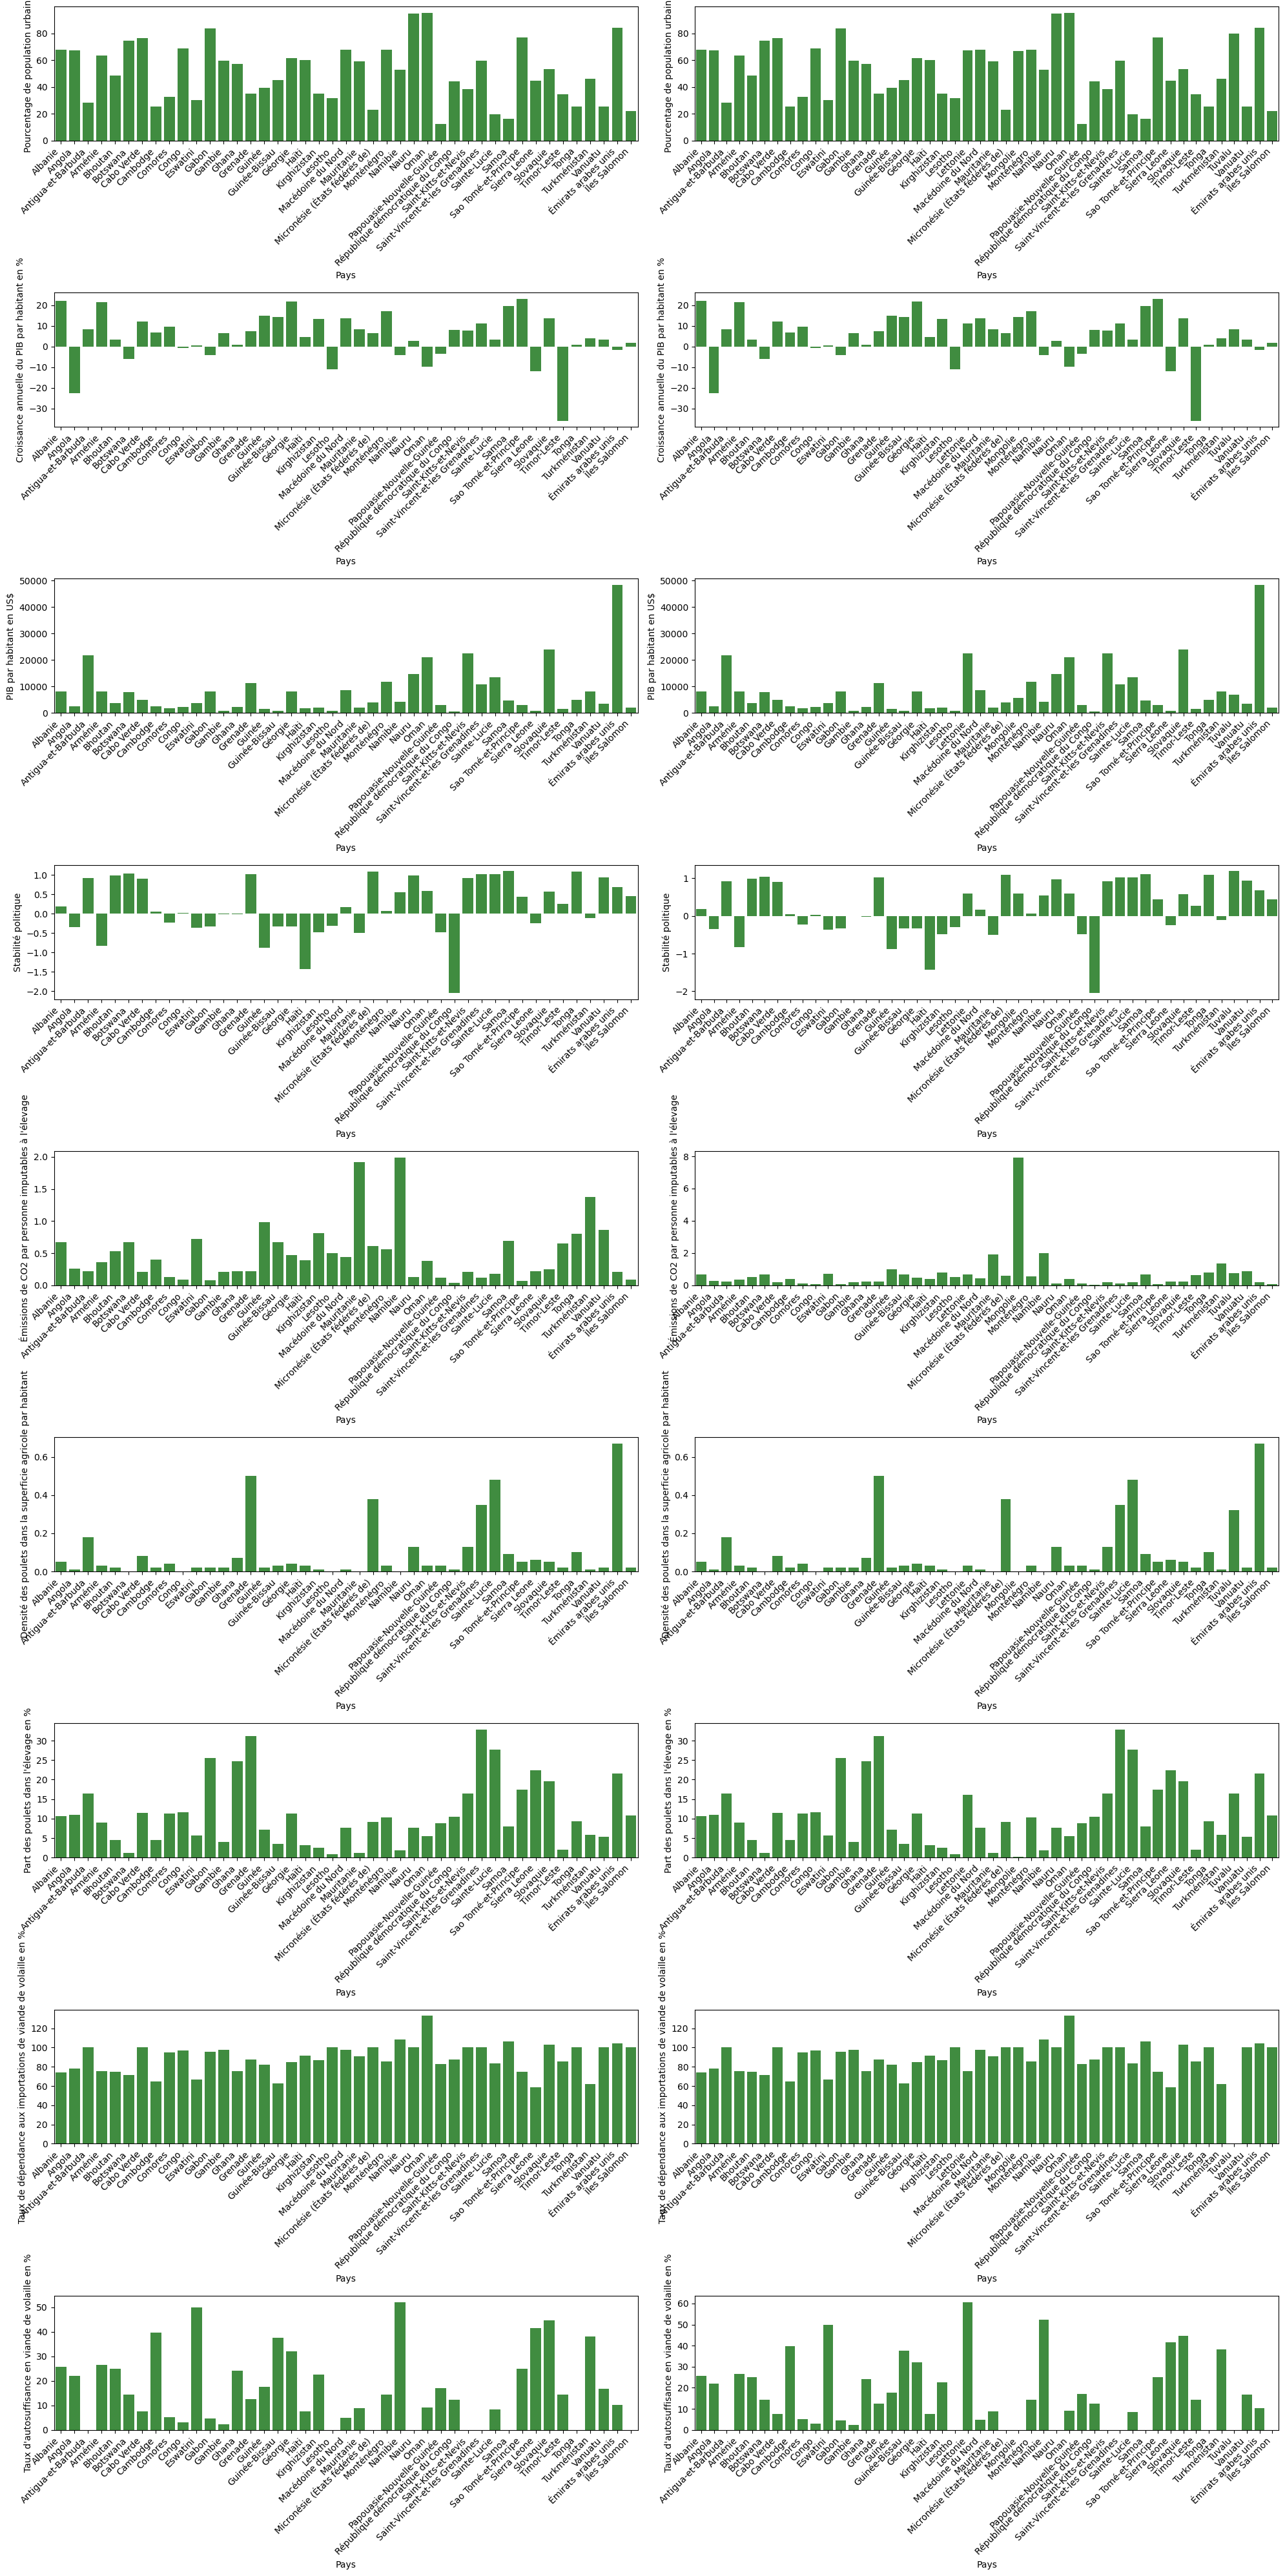

In [54]:
fig, axes = plt.subplots(len(variable_initiales_name),2) 
fig.set_size_inches(20, 40) 
i = 0 
for i, variable_initiale in enumerate(variable_initiales_name): 
    sns.barplot(data=df_chicken_data[df_chicken_data['cluster_dendrogram'] == 1], x='Pays', y=variable_initiale, ax=axes[i, 0], color="#339933") 
    sns.barplot(data=df_chicken_data[df_chicken_data['cluster_4_kmeans'] == 2], x='Pays', y=variable_initiale, ax=axes[i, 1], color="#339933") 

    for ax in axes.flatten():
        for label in ax.get_xticklabels():
            label.set_rotation(45)
            label.set_ha('right')

plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(102, 204, 102);" >
<h3 style="margin: auto; padding: 20px; color: RGB(102, 204, 102); ">5.2 - Comparaison du cluster 2 du dendrogramme et du cluster 0 du k-means</h3>
</div>

In [55]:
pays_cluster_2_dendrogramme = df_chicken_data[df_chicken_data['cluster_dendrogram'] == 2].index

print("Nombre de pays du cluster 1 du dendrogramme", pays_cluster_2_dendrogramme.shape[0])
pays_cluster_2_dendrogramme

Nombre de pays du cluster 1 du dendrogramme 93


Index(['Afghanistan', 'Afrique du Sud', 'Algérie', 'Arabie saoudite',
       'Argentine', 'Azerbaïdjan', 'Bangladesh', 'Belize',
       'Bolivie (État plurinational de)', 'Bosnie-Herzégovine', 'Brésil',
       'Burkina Faso', 'Bélarus', 'Cameroun', 'Chili',
       'Chine, Taiwan Province de', 'Chine, continentale', 'Colombie',
       'Costa Rica', 'Croatie', 'Côte d'Ivoire', 'El Salvador', 'Estonie',
       'Fidji', 'Fédération de Russie', 'Guatemala', 'Guyana', 'Honduras',
       'Hongrie', 'Inde', 'Indonésie', 'Iran (République islamique d')',
       'Iraq', 'Israël', 'Jamaïque', 'Jordanie', 'Kazakhstan', 'Kenya',
       'Kiribati', 'Lettonie', 'Liban', 'Libye', 'Libéria', 'Lituanie',
       'Madagascar', 'Malaisie', 'Malawi', 'Maroc', 'Maurice', 'Mexique',
       'Mozambique', 'Myanmar', 'Nicaragua', 'Niger', 'Nigéria', 'Népal',
       'Ouganda', 'Ouzbékistan', 'Pakistan', 'Panama', 'Paraguay',
       'Philippines', 'Pologne', 'Pérou', 'Roumanie', 'Rwanda',
       'République arabe 

In [56]:
pays_cluster_0_kmeans = df_chicken_data[df_chicken_data['cluster_4_kmeans'] == 0].index

print("Nombre de pays du cluster 1 du dendrogramme", pays_cluster_0_kmeans.shape[0])
pays_cluster_0_kmeans

Nombre de pays du cluster 1 du dendrogramme 68


Index(['Afghanistan', 'Afrique du Sud', 'Algérie', 'Azerbaïdjan', 'Bangladesh',
       'Belize', 'Bolivie (État plurinational de)', 'Bosnie-Herzégovine',
       'Brésil', 'Burkina Faso', 'Bélarus', 'Cameroun', 'Chili',
       'Chine, continentale', 'Colombie', 'Côte d'Ivoire', 'El Salvador',
       'Fidji', 'Fédération de Russie', 'Guatemala', 'Honduras', 'Inde',
       'Iran (République islamique d')', 'Iraq', 'Jamaïque', 'Jordanie',
       'Kazakhstan', 'Kenya', 'Libye', 'Libéria', 'Madagascar', 'Malawi',
       'Maroc', 'Mexique', 'Mozambique', 'Myanmar', 'Nicaragua', 'Niger',
       'Nigéria', 'Népal', 'Ouganda', 'Ouzbékistan', 'Pakistan', 'Panama',
       'Paraguay', 'Philippines', 'Pérou', 'Roumanie', 'Rwanda',
       'République arabe syrienne', 'République démocratique populaire lao',
       'République-Unie de Tanzanie', 'Serbie', 'Sri Lanka', 'Sénégal',
       'Tadjikistan', 'Thaïlande', 'Tunisie', 'Türkiye', 'Ukraine',
       'Venezuela (République bolivarienne du)', 'Viet N

In [57]:
print("Pays se trouvant dans le cluster 2 du dendrogramme et ne se trouvant pas dans le cluster 0 du kmean")
pays_cluster_2_dendrogramme[~pays_cluster_2_dendrogramme.isin(pays_cluster_0_kmeans)]

Pays se trouvant dans le cluster 2 du dendrogramme et ne se trouvant pas dans le cluster 0 du kmean


Index(['Arabie saoudite', 'Argentine', 'Chine, Taiwan Province de',
       'Costa Rica', 'Croatie', 'Estonie', 'Guyana', 'Hongrie', 'Indonésie',
       'Israël', 'Kiribati', 'Lettonie', 'Liban', 'Lituanie', 'Malaisie',
       'Maurice', 'Pologne', 'République de Corée', 'République de Moldova',
       'République dominicaine', 'Seychelles', 'Slovénie', 'Suriname',
       'Tchéquie', 'Tuvalu'],
      dtype='object', name='Pays')

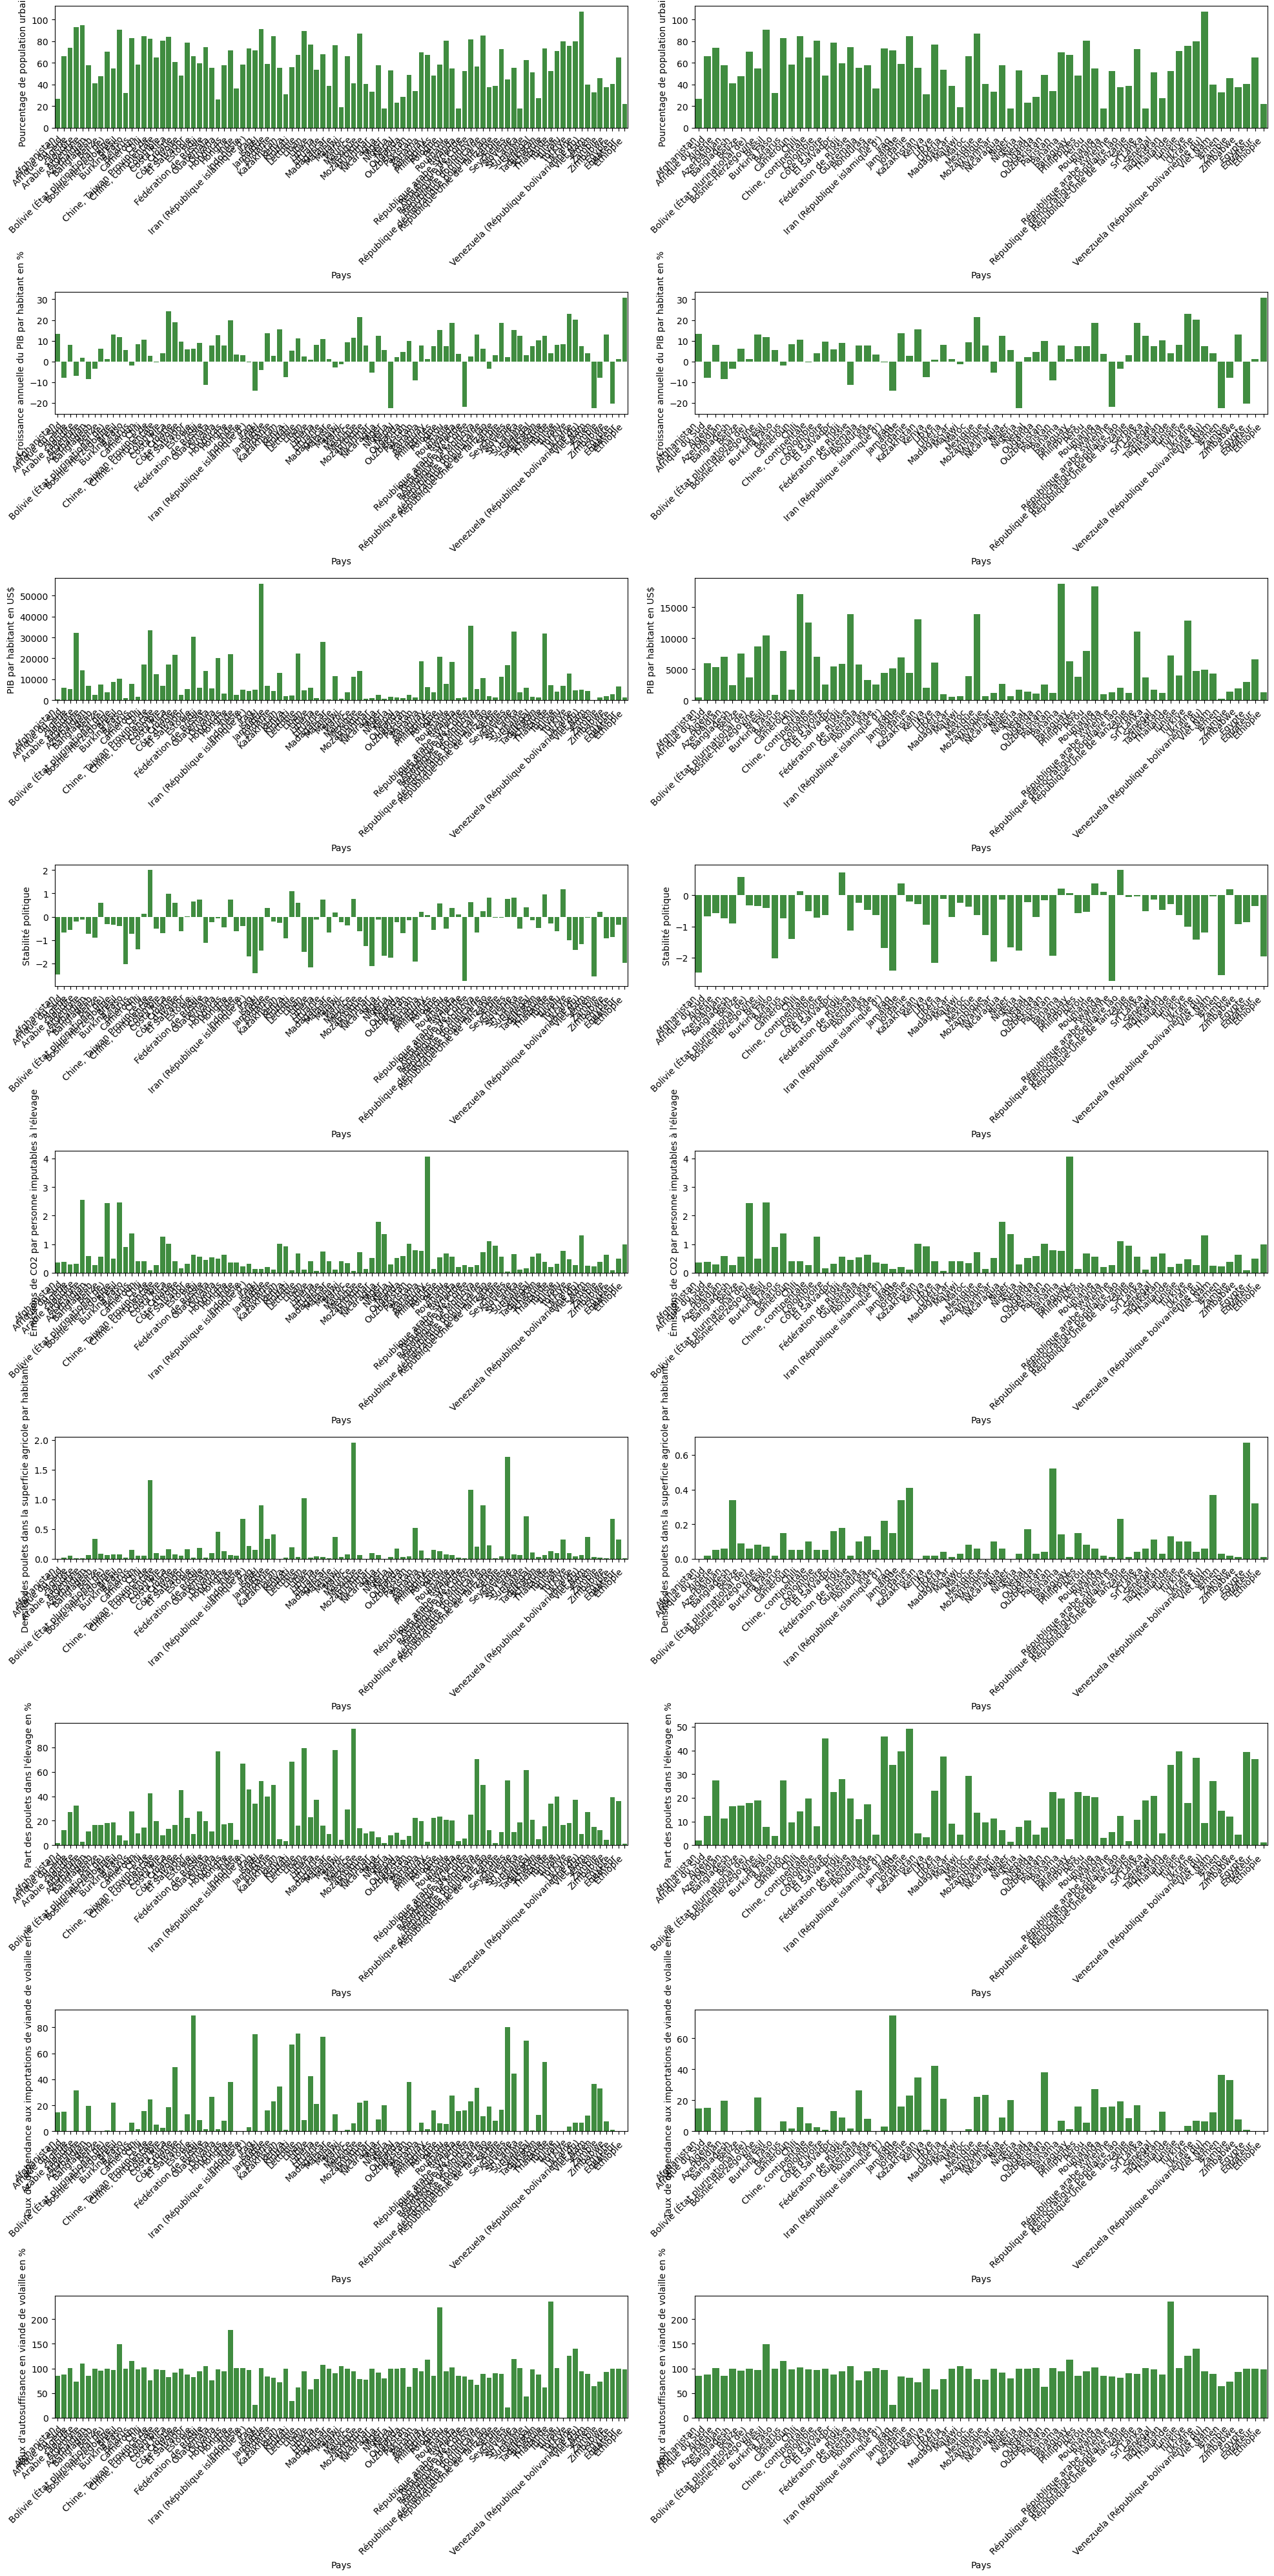

In [58]:
fig, axes = plt.subplots(len(variable_initiales_name),2) 
fig.set_size_inches(20, 40) 
i = 0 
for i, variable_initiale in enumerate(variable_initiales_name): 
    sns.barplot(data=df_chicken_data[df_chicken_data['cluster_dendrogram'] == 2], x='Pays', y=variable_initiale, ax=axes[i, 0], color="#339933") 
    sns.barplot(data=df_chicken_data[df_chicken_data['cluster_4_kmeans'] == 0], x='Pays', y=variable_initiale, ax=axes[i, 1], color="#339933") 

    for ax in axes.flatten():
        for label in ax.get_xticklabels():
            label.set_rotation(45)
            label.set_ha('right')

plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(102, 204, 102);" >
<h3 style="margin: auto; padding: 20px; color: RGB(102, 204, 102); ">5.3 - Comparaison du cluster 3 du dendrogramme et du cluster 1 du k-means</h3>
</div>

In [59]:
pays_cluster_3_dendrogramme = df_chicken_data[df_chicken_data['cluster_dendrogram'] == 3].index
print("Nombre de pays du cluster 3 du dendrogramme", pays_cluster_3_dendrogramme.shape[0])

pays_cluster_3_dendrogramme


Nombre de pays du cluster 3 du dendrogramme 7


Index(['Bahamas', 'Bahreïn', 'Barbade', 'Chine - RAS de Hong-Kong', 'Koweït',
       'Qatar', 'Trinité-et-Tobago'],
      dtype='object', name='Pays')

In [60]:
pays_cluster_1_kmeans = df_chicken_data[df_chicken_data['cluster_4_kmeans'] == 1].index
print("Nombre de pays du cluster 1 du kmean", pays_cluster_1_kmeans.shape[0])

pays_cluster_1_kmeans

Nombre de pays du cluster 1 du kmean 18


Index(['Bahamas', 'Bahreïn', 'Barbade', 'Chine - RAS de Hong-Kong', 'Guyana',
       'Indonésie', 'Israël', 'Kiribati', 'Koweït', 'Liban', 'Malaisie',
       'Maurice', 'Qatar', 'République de Moldova', 'République dominicaine',
       'Seychelles', 'Suriname', 'Trinité-et-Tobago'],
      dtype='object', name='Pays')

In [61]:
print("Pays se trouvant dans le cluster 1 du kmean et ne se trouvant pas dans le cluster 3 du dendrogramme")
pays_cluster_1_kmeans[~pays_cluster_1_kmeans.isin(pays_cluster_3_dendrogramme)]


Pays se trouvant dans le cluster 1 du kmean et ne se trouvant pas dans le cluster 3 du dendrogramme


Index(['Guyana', 'Indonésie', 'Israël', 'Kiribati', 'Liban', 'Malaisie',
       'Maurice', 'République de Moldova', 'République dominicaine',
       'Seychelles', 'Suriname'],
      dtype='object', name='Pays')

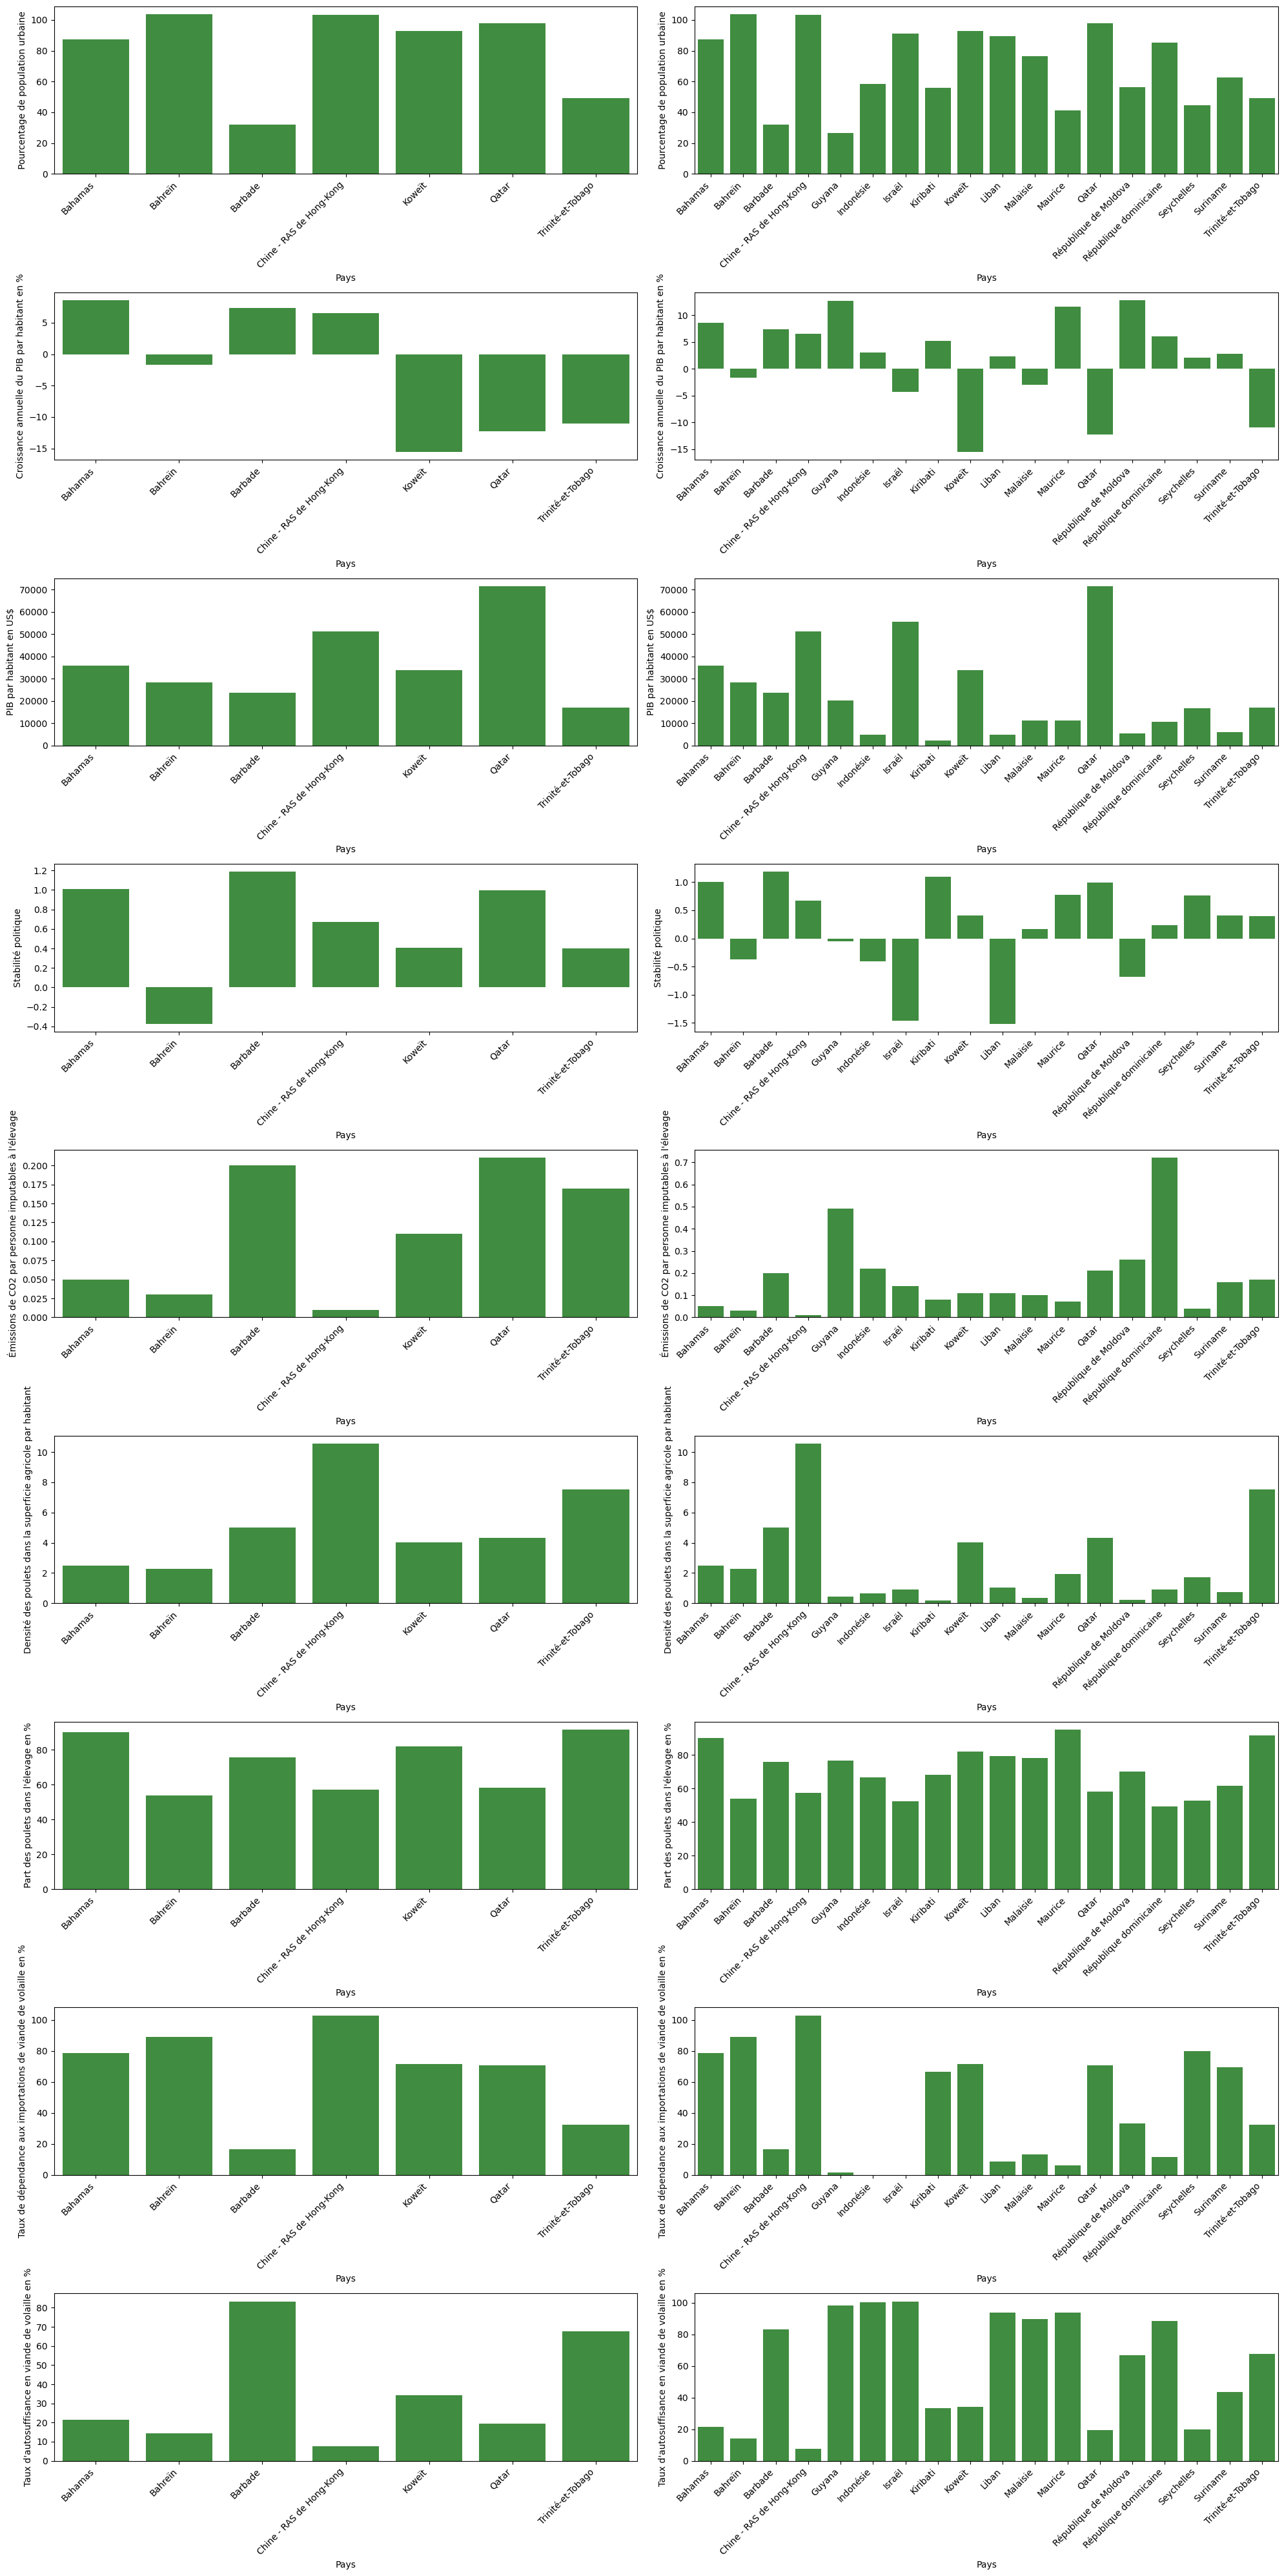

In [62]:
fig, axes = plt.subplots(len(variable_initiales_name),2) 
fig.set_size_inches(20, 40) 
i = 0 
for i, variable_initiale in enumerate(variable_initiales_name): 
    sns.barplot(data=df_chicken_data[df_chicken_data['cluster_dendrogram'] == 3], x='Pays', y=variable_initiale, ax=axes[i, 0], color="#339933") 
    sns.barplot(data=df_chicken_data[df_chicken_data['cluster_4_kmeans'] == 1], x='Pays', y=variable_initiale, ax=axes[i, 1], color="#339933") 

    for ax in axes.flatten():
        for label in ax.get_xticklabels():
            label.set_rotation(45)
            label.set_ha('right')

plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(102, 204, 102);" >
<h3 style="margin: auto; padding: 20px; color: RGB(102, 204, 102); ">5.4 - Comparaison du cluster 4 du dendrogramme et du cluster 3 du k-means</h3>
</div>

In [63]:
pays_cluster_4_dendrogramme = df_chicken_data[df_chicken_data['cluster_dendrogram'] == 4].index
print("Nombre de pays du cluster 4 du dendrogramme", pays_cluster_4_dendrogramme.shape[0])
pays_cluster_4_dendrogramme


Nombre de pays du cluster 4 du dendrogramme 16


Index(['Allemagne', 'Australie', 'Belgique', 'Canada', 'Danemark', 'Finlande',
       'France', 'Islande', 'Mongolie', 'Norvège', 'Nouvelle-Zélande',
       'Pays-Bas (Royaume des)',
       'Royaume-Uni de Grande-Bretagne et d'Irlande du Nord', 'Suisse',
       'Uruguay', 'États-Unis d'Amérique'],
      dtype='object', name='Pays')

In [64]:
pays_cluster_3_kmeans = df_chicken_data[df_chicken_data['cluster_4_kmeans'] == 3].index
print("Nombre de pays du cluster 3 du kmean", pays_cluster_3_kmeans.shape[0])
pays_cluster_3_kmeans

Nombre de pays du cluster 3 du kmean 27


Index(['Allemagne', 'Arabie saoudite', 'Argentine', 'Australie', 'Belgique',
       'Canada', 'Chine, Taiwan Province de', 'Costa Rica', 'Croatie',
       'Danemark', 'Estonie', 'Finlande', 'France', 'Hongrie', 'Islande',
       'Lituanie', 'Norvège', 'Nouvelle-Zélande', 'Pays-Bas (Royaume des)',
       'Pologne', 'Royaume-Uni de Grande-Bretagne et d'Irlande du Nord',
       'République de Corée', 'Slovénie', 'Suisse', 'Tchéquie', 'Uruguay',
       'États-Unis d'Amérique'],
      dtype='object', name='Pays')

In [65]:
print("Pays se trouvant dans le cluster 3 du kmean et ne se trouvant pas dans le cluster 4 du dendrogramme")
pays_cluster_3_kmeans[~pays_cluster_3_kmeans.isin(pays_cluster_4_dendrogramme)]

Pays se trouvant dans le cluster 3 du kmean et ne se trouvant pas dans le cluster 4 du dendrogramme


Index(['Arabie saoudite', 'Argentine', 'Chine, Taiwan Province de',
       'Costa Rica', 'Croatie', 'Estonie', 'Hongrie', 'Lituanie', 'Pologne',
       'République de Corée', 'Slovénie', 'Tchéquie'],
      dtype='object', name='Pays')

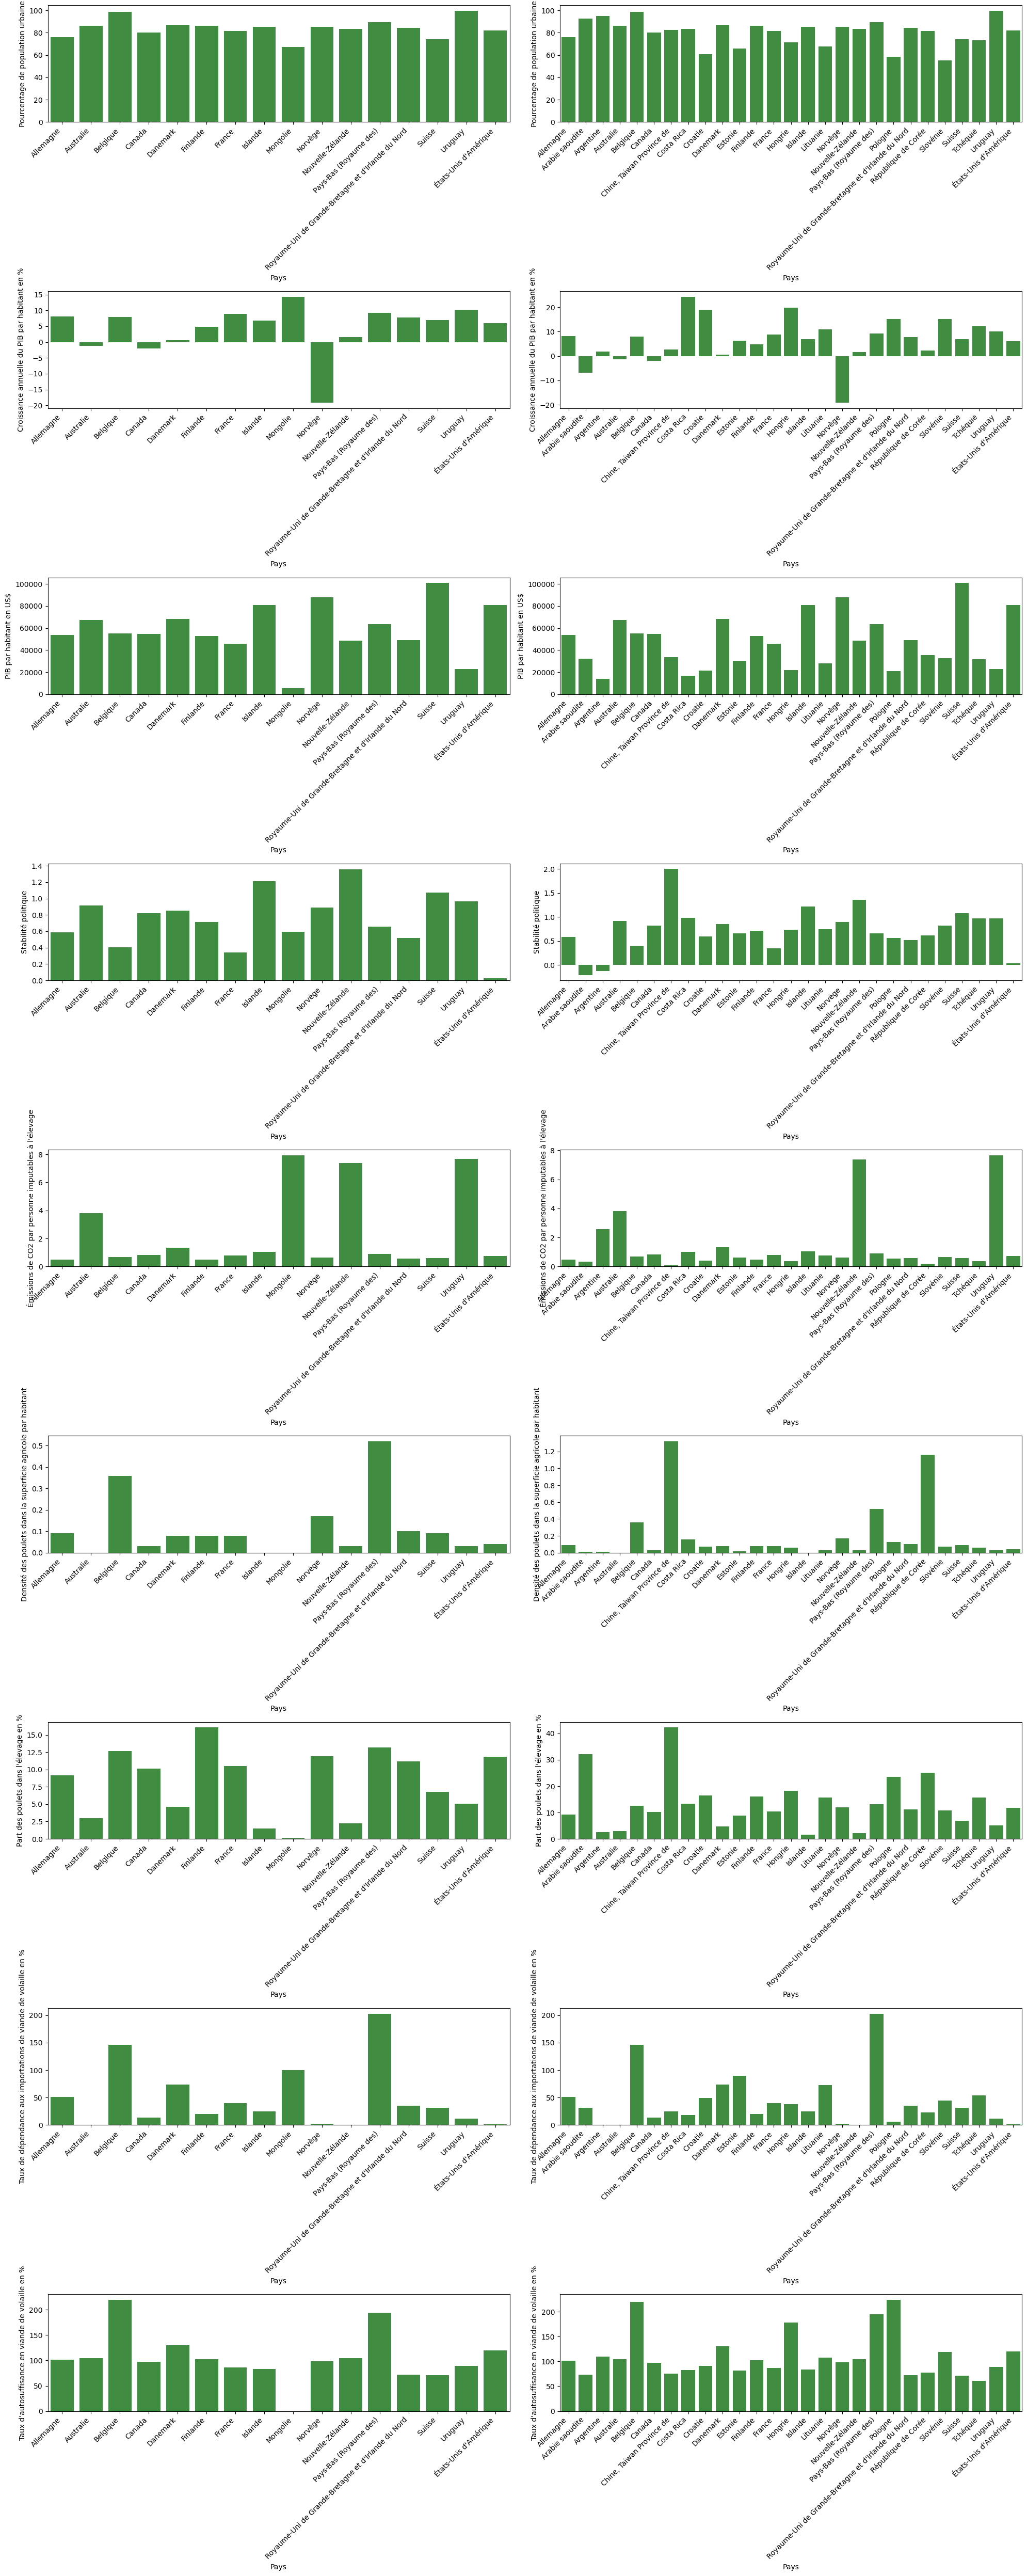

In [66]:
fig, axes = plt.subplots(len(variable_initiales_name),2) 
fig.set_size_inches(20, 50) 
i = 0 
for i, variable_initiale in enumerate(variable_initiales_name): 
    sns.barplot(data=df_chicken_data[df_chicken_data['cluster_dendrogram'] == 4], x='Pays', y=variable_initiale, ax=axes[i, 0], color="#339933") 
    sns.barplot(data=df_chicken_data[df_chicken_data['cluster_4_kmeans'] == 3], x='Pays', y=variable_initiale, ax=axes[i, 1], color="#339933") 

    for ax in axes.flatten():
        for label in ax.get_xticklabels():
            label.set_rotation(45)
            label.set_ha('right')

plt.tight_layout()
plt.show()

<div style="background-color: RGB(102, 204, 102);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 6 - Choix des pays</h2>
</div>

<div>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(102,204,102);">
    Nous allons choisir les pays qui sont dans le cluster 4 du dendrogramme car ils ont un PIB élevé
</p>
</div>

In [67]:
#Dataframe contenant les pays ayant un PIB élevé
df_chicken_data_pib_eleve = df_chicken_data[(df_chicken_data["PIB par habitant en US$"] >= 20000)]

In [68]:
df_cluster_pib_eleve = df_chicken_data_pib_eleve[df_chicken_data_pib_eleve["cluster_dendrogram"] == 4].sort_values("Taux de dépendance aux importations de viande de volaille en %", ascending=False)

In [69]:
print("D'après le méthode du dendrogrammme il y a {} pays émergents dépendant de l'importation de viande de volaille".format(df_cluster_pib_eleve.shape[0]))

D'après le méthode du dendrogrammme il y a 15 pays émergents dépendant de l'importation de viande de volaille


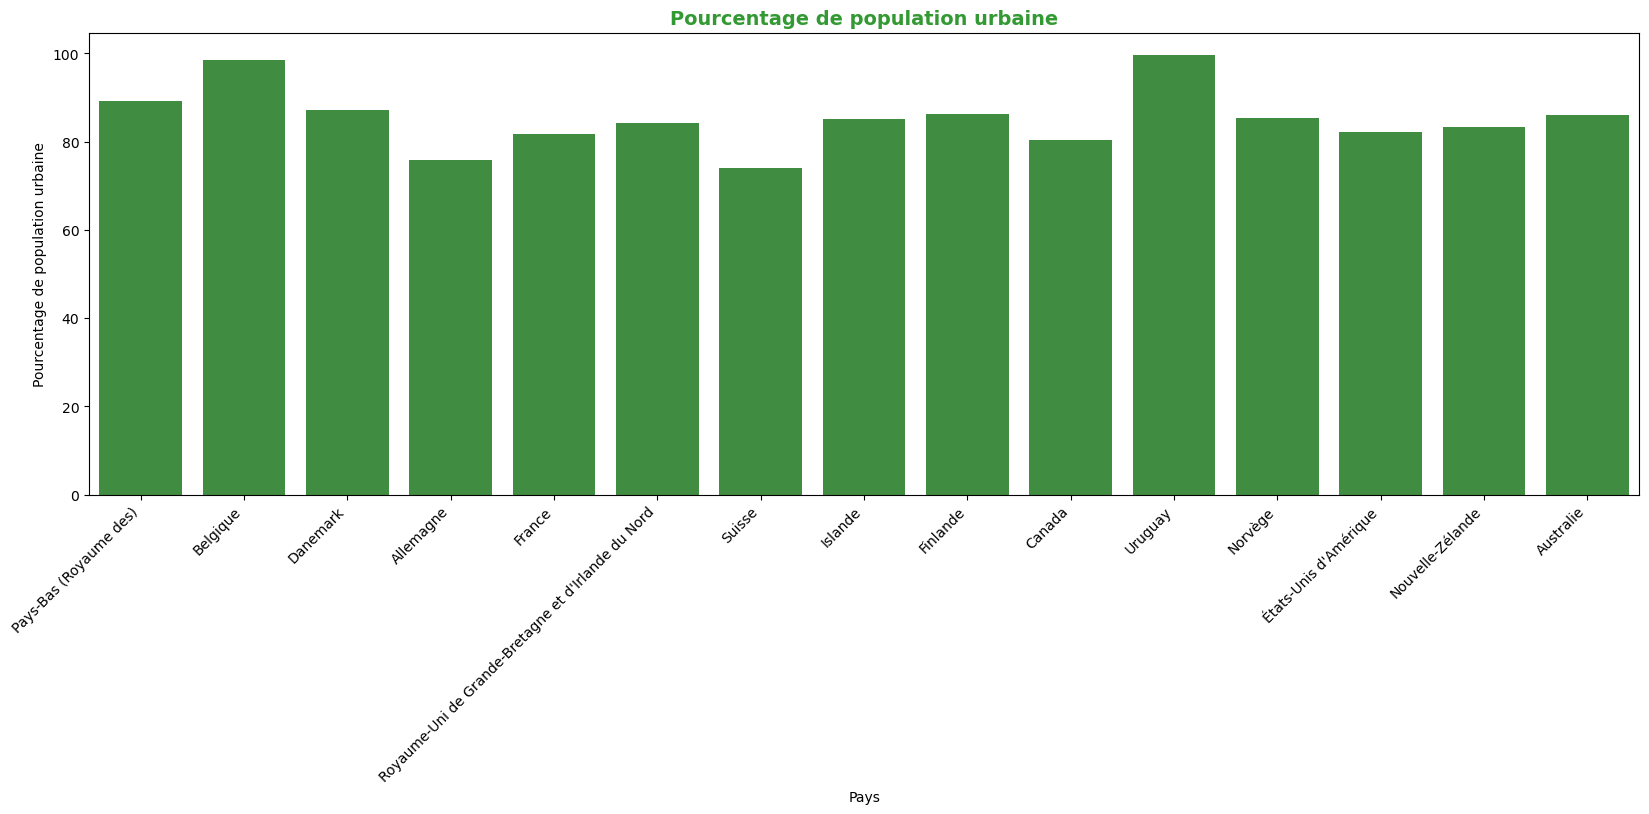

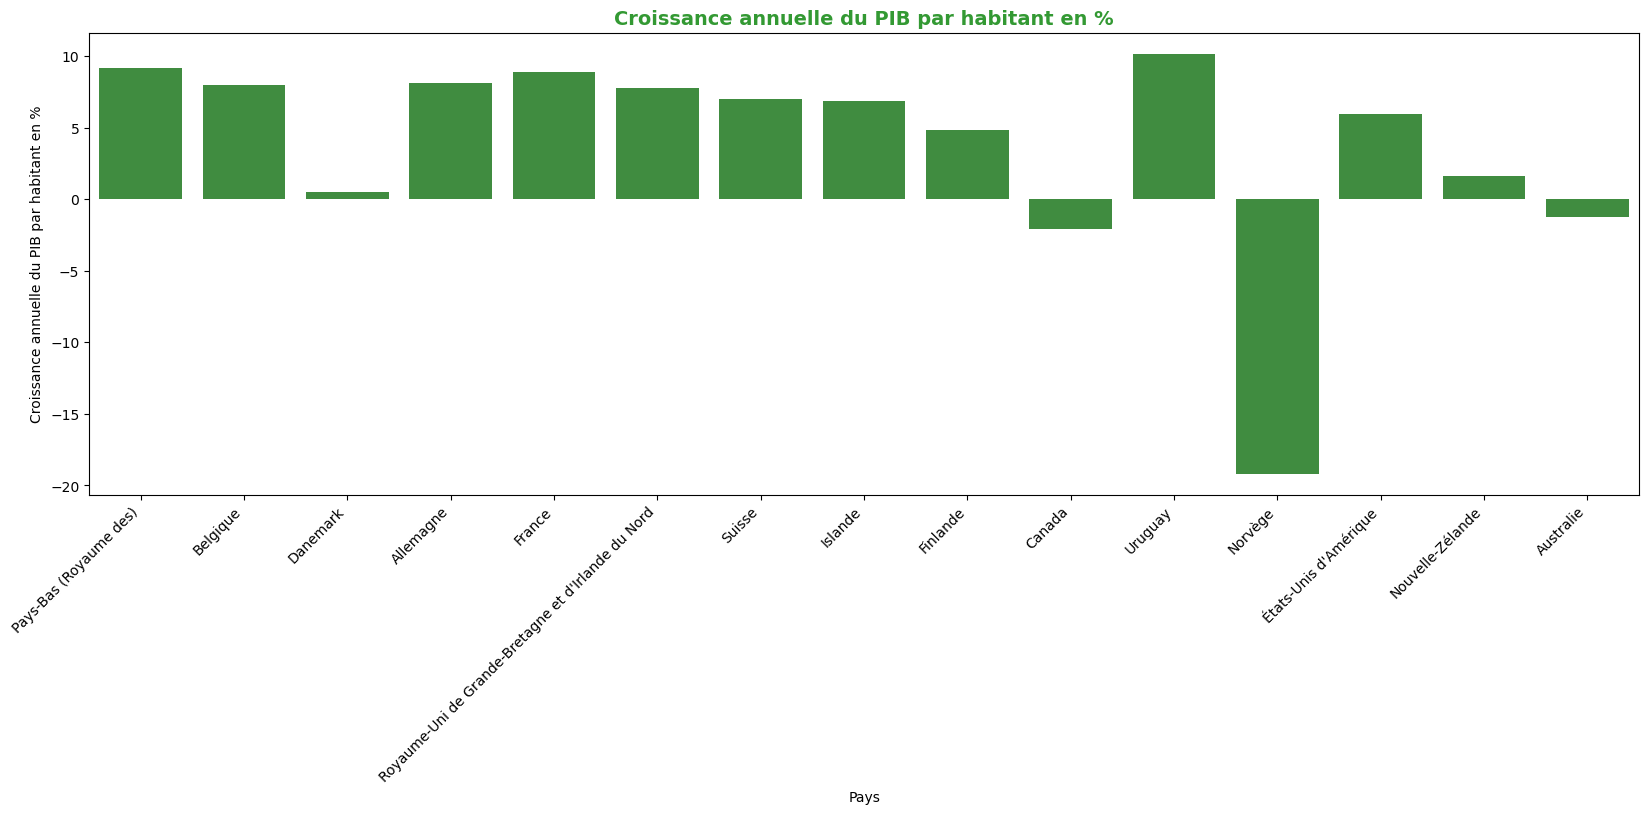

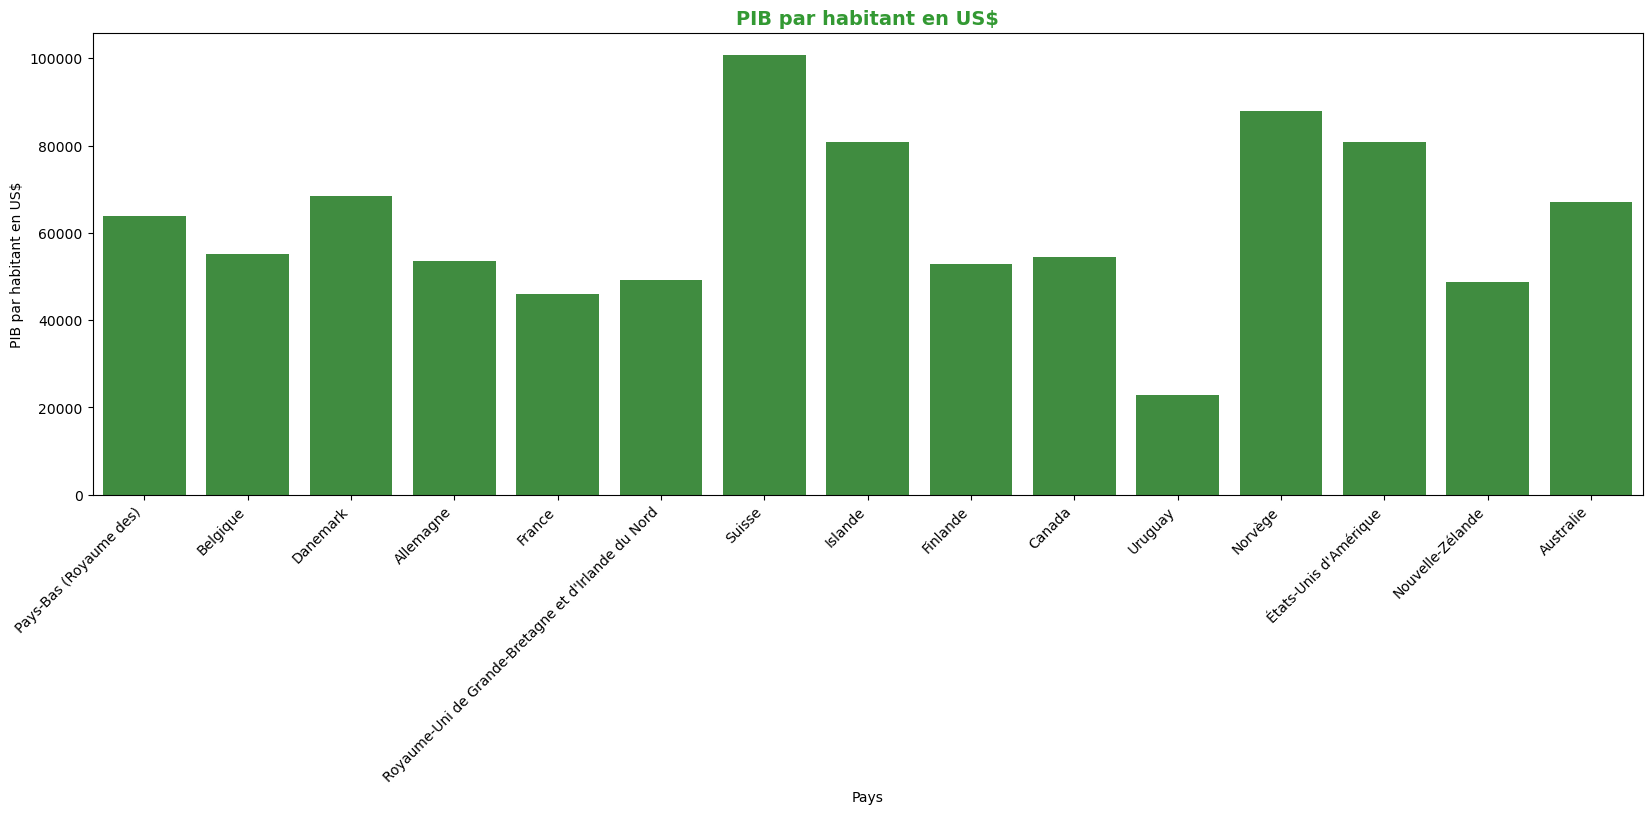

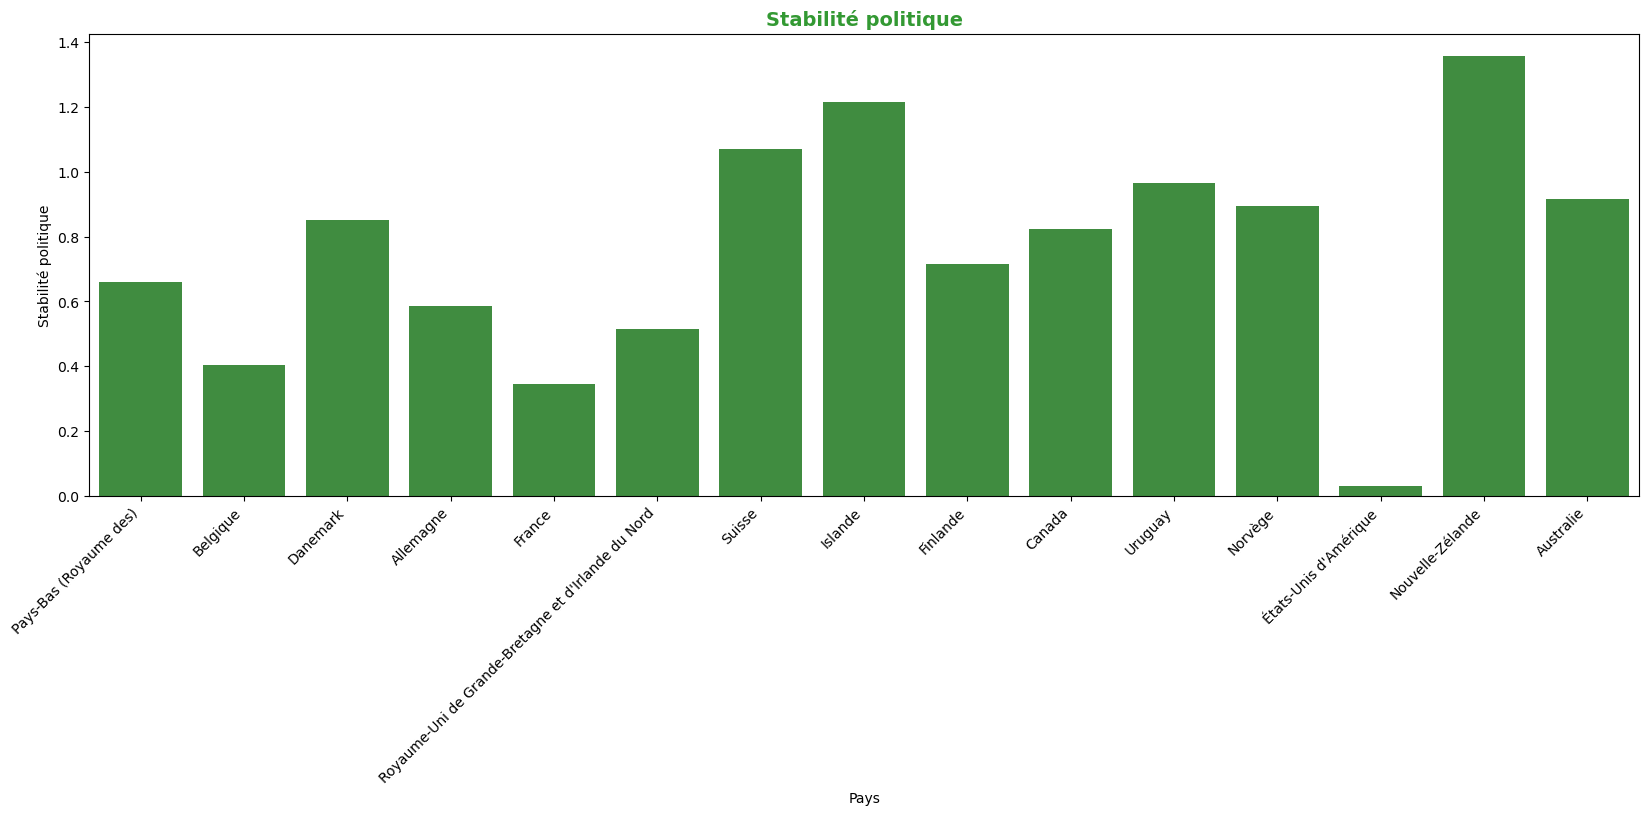

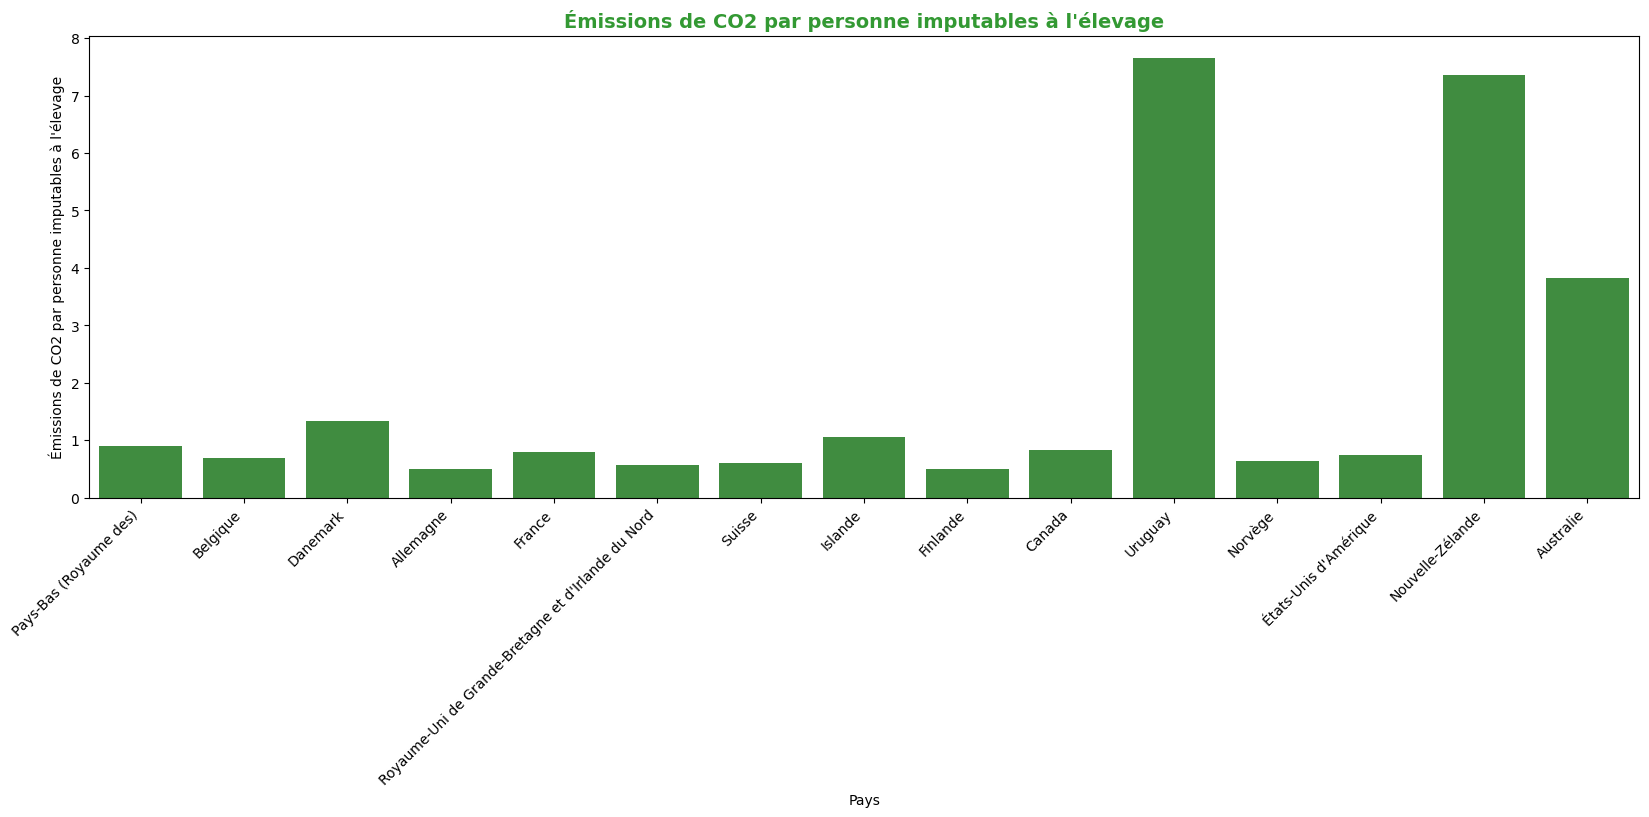

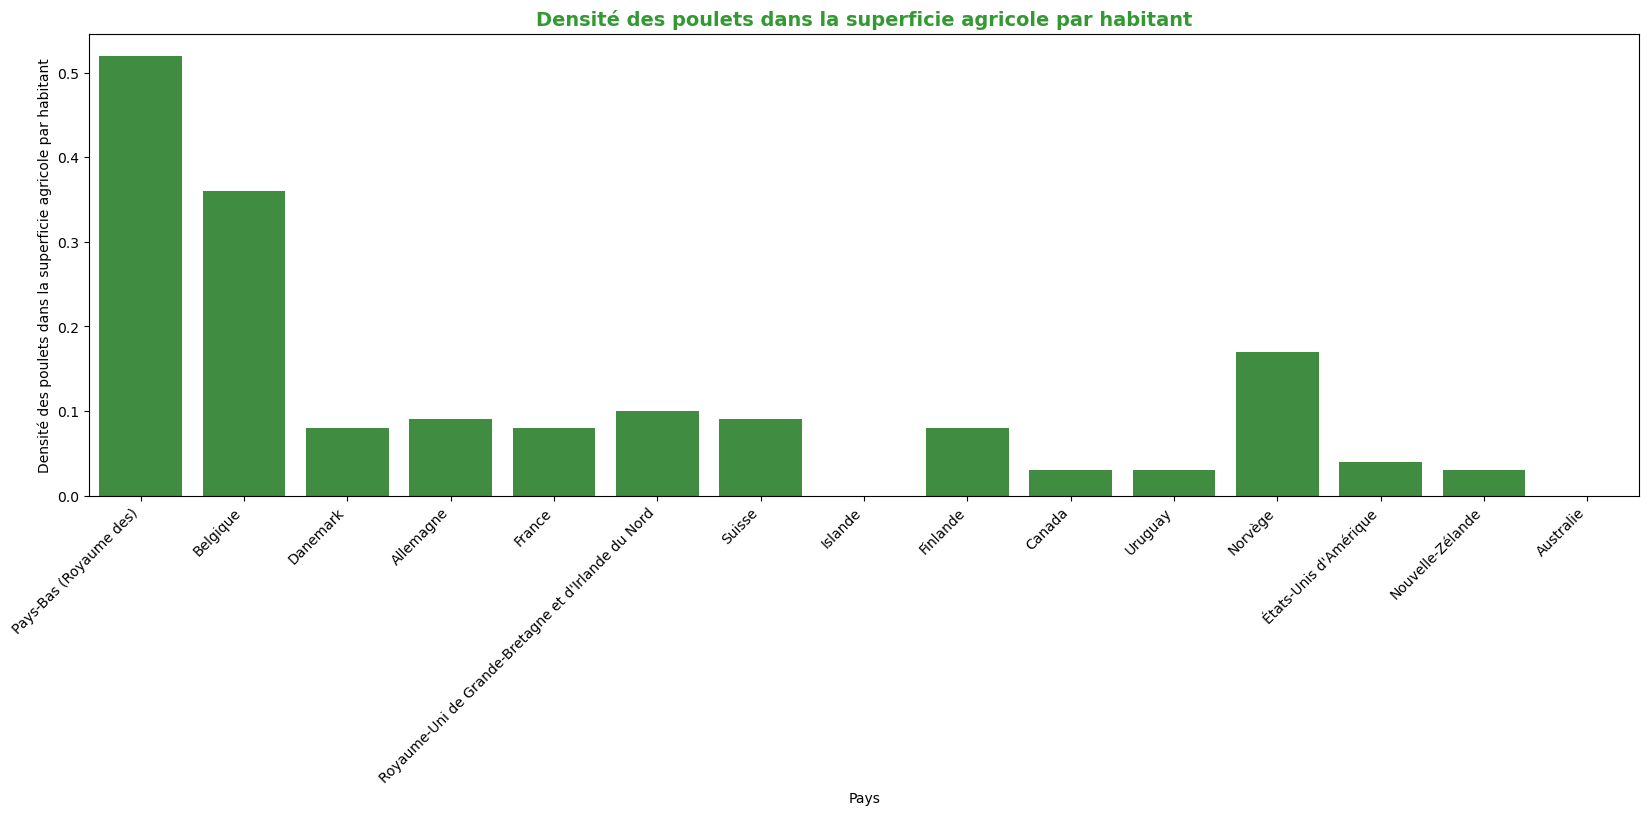

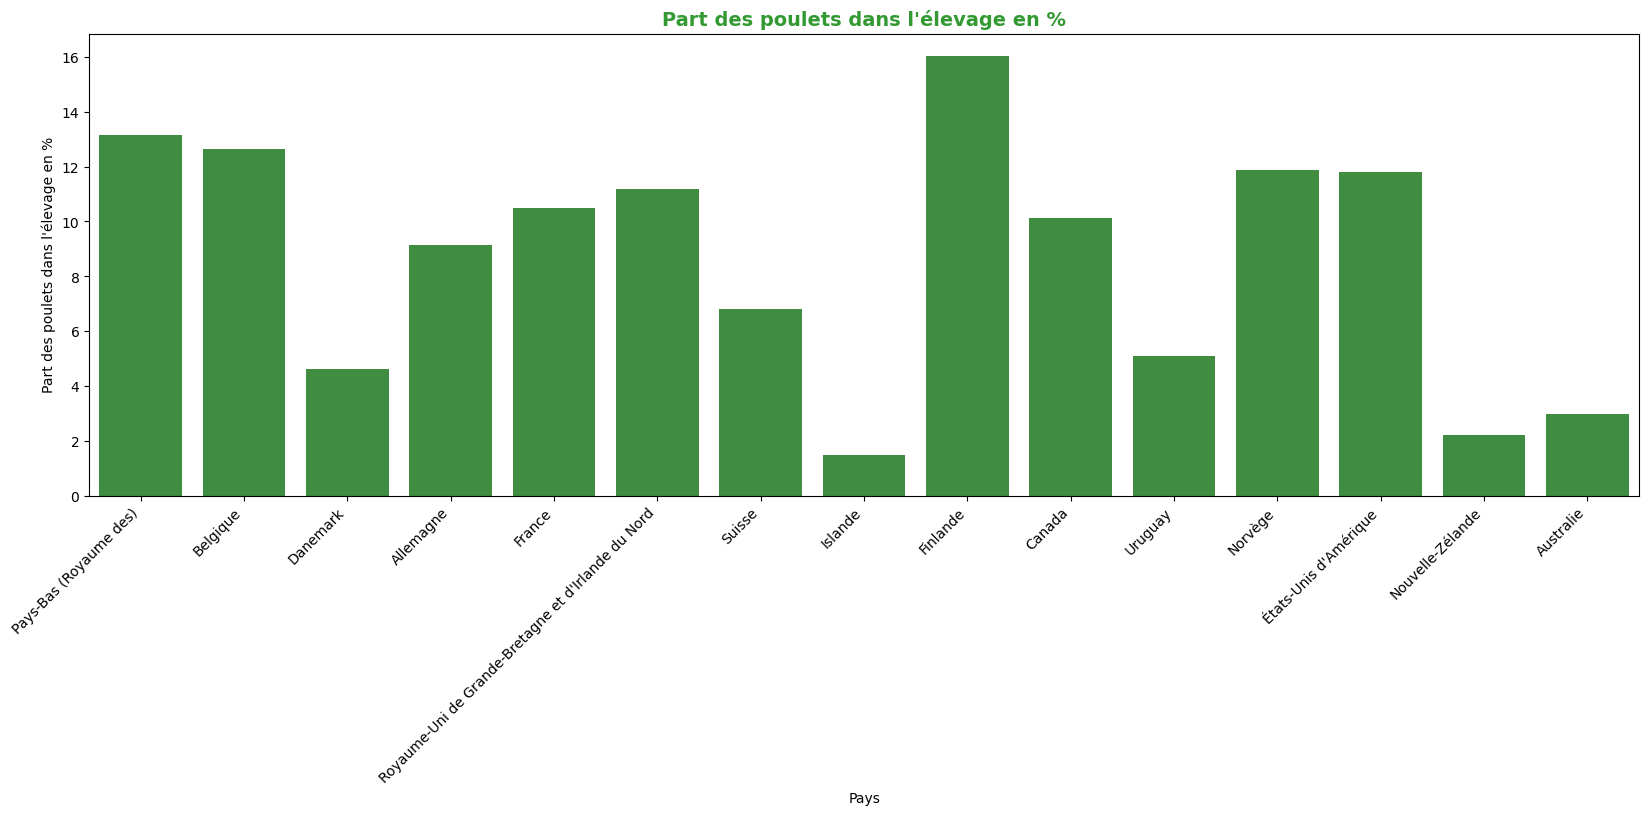

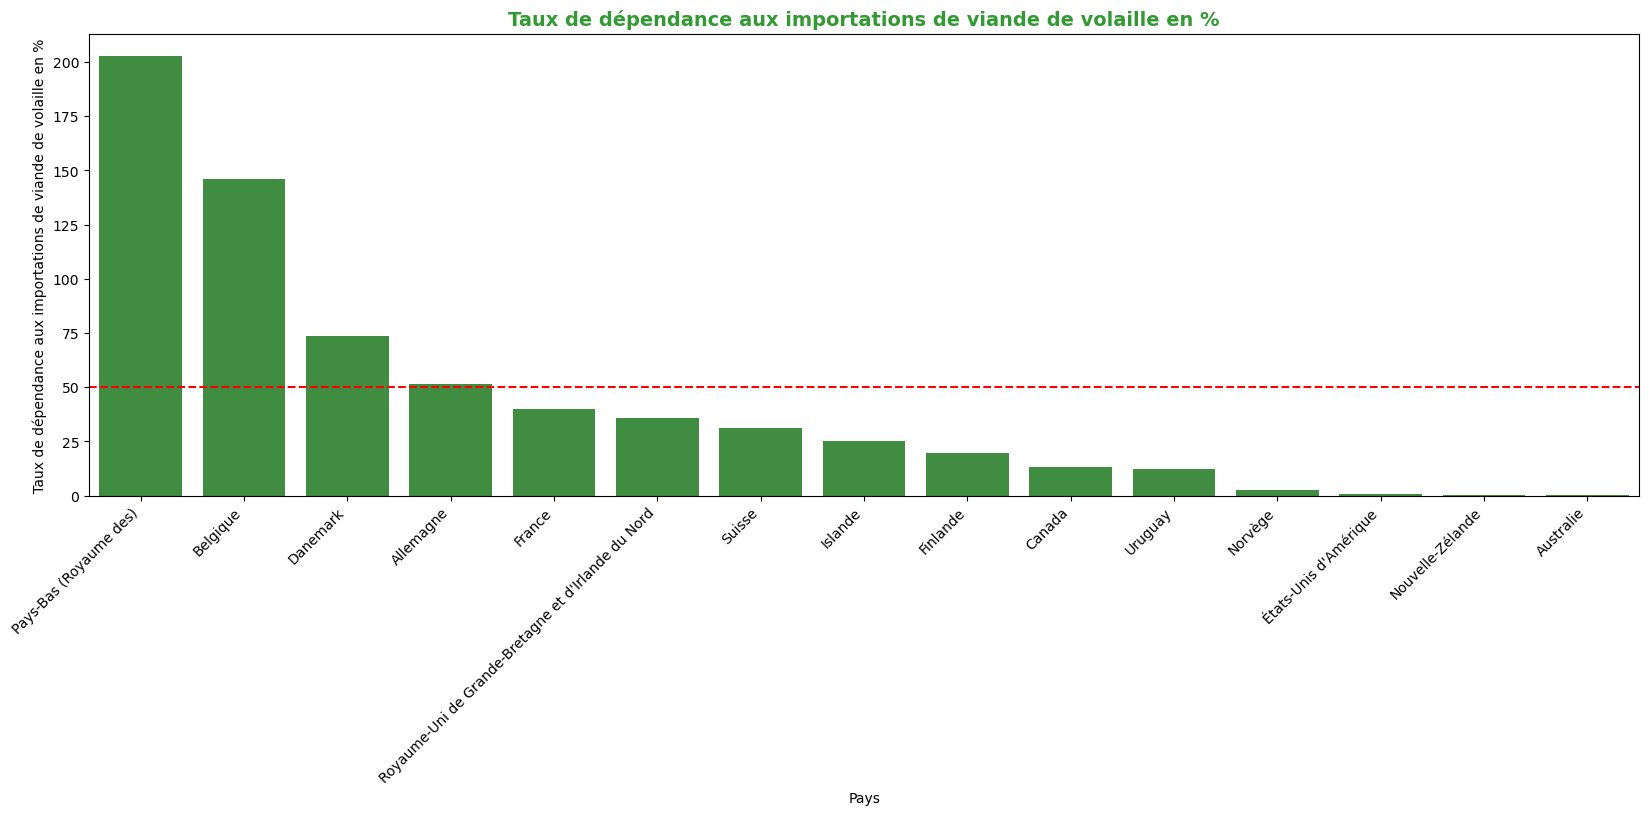

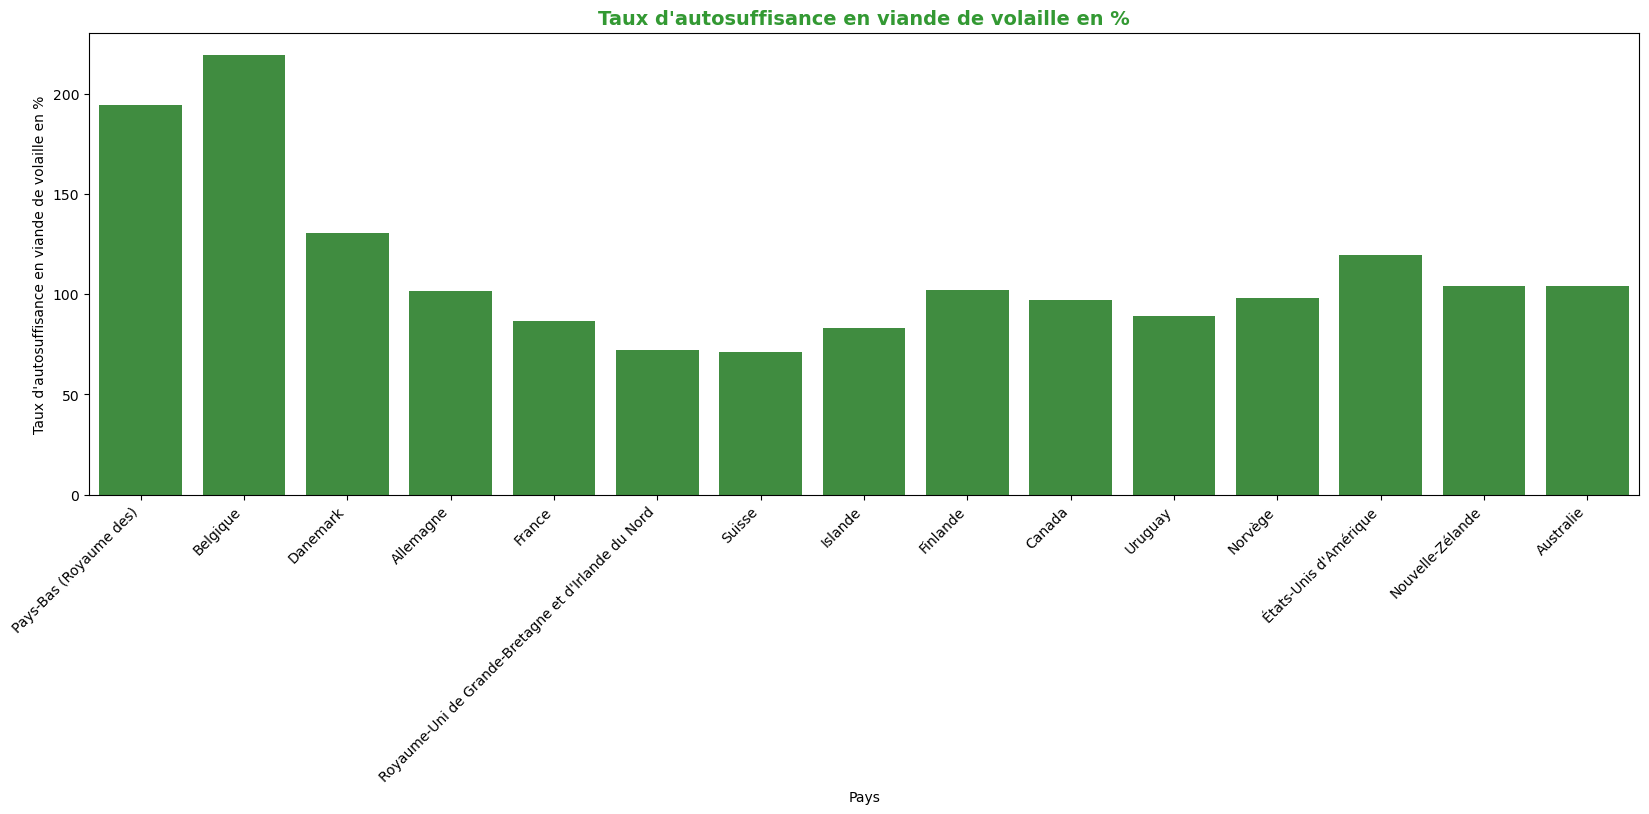

In [70]:
for variable_initiales in variable_initiales_name:
    plt.figure(figsize=(20, 6))
    sns.barplot(data=df_cluster_pib_eleve, x='Pays', y=variable_initiales, color="#339933")
    plt.xticks(rotation=45, ha='right')

    plt.title(variable_initiales, fontsize=14, weight='bold', color="#339933")

    if variable_initiales == "Taux de dépendance aux importations de viande de volaille en %":
        plt.axhline(50, color="red", linestyle="dashed")
    plt.show()

<div style="border: 1px solid RGB(102, 204, 102);" >
<h3 style="margin: auto; padding: 20px; color: RGB(102, 204, 102); ">6.3 - Pays choisis</h3>
</div>

<div>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(102,204,102);">
    Nous conseillons à la socété "La poule qui chante" d'exporter ses poulets vers les pays industrialisé dépendants de l'importation de viande de volaille:
    <ul style="color: RGB(102,204,102)">
        <li>Pays-Bas</li>
        <li>Bélgique</li>
        <li>Danemark</li>
        <li>Allemagne</li>
    </ul>
</p>
</div>